# 파워리프팅 체중과 최고 Dots 점수의 인과분석

이 노트북은 전처리된 OpenPowerlifting 남성·여성 데이터를 이용하여 보고서의 전체 분석을 한 흐름으로 재현한다.

**분석 순서**

1. 데이터 로드와 품질 점검
2. 성별 체급 설정 및 분석 표본 구성
3. 30일 보간과 EMA를 이용한 선수별 생애주기 지표 추출
4. 기술통계·분포·상관관계·산점도
5. 다중회귀, VIF, 잔차진단, 1,000회 부트스트랩
6. 초기 발전속도의 매개효과 확인
7. PSM/CEM과 Q1-Q3 임계값 민감도 분석
8. Love plot을 이용한 공변량 균형 점검
9. GPS-DR 및 restricted cubic spline 용량-반응 곡선
10. 표·그래프·중간 산출물 저장

> 관찰자료 기반 분석이므로 모든 인과 해석은 측정된 공변량에 대한 조건부 해석이다. 훈련, 영양, 신장, 체지방률 같은 미측정 교란요인은 남는다.


## 0. 실행 전 확인

노트북은 `C:\python\powerlift_causal_analysis` 폴더에 두고 실행하는 것을 기준으로 한다.

필요한 입력 파일:

- `data/cleaned_sss_M.csv`
- `data/cleaned_sss_F.csv`

아직 파일이 없다면 먼저 `preprocess_code/preprocess.py`를 실행한다.

필요한 패키지가 없다면 아래 명령의 주석을 해제해 한 번만 실행한다.


In [ ]:
# 필요 시 주석을 해제해 실행하세요.
# %pip install pandas numpy scipy statsmodels scikit-learn matplotlib seaborn tqdm openpyxl patsy


## 1. 라이브러리와 전역 설정


In [60]:
from pathlib import Path
from dataclasses import dataclass
import json
import platform
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import linregress, norm, pearsonr
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KernelDensity, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from joblib import Parallel, delayed
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
np.random.seed(42)

sns.set_theme(style="whitegrid", context="notebook")
try:
    plt.rcParams["font.family"] = "Malgun Gothic"
except Exception:
    pass
plt.rcParams["axes.unicode_minus"] = False

print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("pandas:", pd.__version__)


Python: 3.12.13
OS: Windows-11-10.0.26200-SP0
pandas: 3.0.3


In [61]:
import matplotlib.font_manager as fm

fonts = sorted(set(f.name for f in fm.fontManager.ttflist))
print("Malgun Gothic" in fonts)

True


In [96]:
# 완전 재현 모드(True): 보고서 수준의 반복 횟수 사용
# 빠른 구조 점검(False): 반복 횟수를 줄여 실행
FULL_RUN = True
RANDOM_SEED = 42

OLS_BOOTSTRAP_ITERATIONS = 1_000 if FULL_RUN else 100
MATCHING_ITERATIONS = 100 if FULL_RUN else 20
GPS_BOOTSTRAP_ITERATIONS = 100 if FULL_RUN else 10

MIN_RECORDS_PER_ATHLETE = 6
GROWTH_THRESHOLD_RATIO = 0.70
MIN_CAREER_DAYS = 180
EMA_PERIOD_RATIO = 0.20
RESAMPLE_DAYS = 30

# True면 선수별 EMA 지표를 다시 계산한다. False면 캐시가 있을 때 재사용한다.
REBUILD_ATHLETE_FEATURES = False

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
DERIVED_DIR = OUTPUT_DIR / "derived"
TABLE_DIR = OUTPUT_DIR / "tables"
for directory in [OUTPUT_DIR, FIGURE_DIR, DERIVED_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DATA_PATHS = {
    "M": DATA_DIR / "cleaned_sss_M.csv",
    "F": DATA_DIR / "cleaned_sss_F.csv",
}

SEX_LABEL = {"M": "남성", "F": "여성"}
WEIGHT_CLASS_CONFIG = {
    "M": {
        "bins": [50, 60, 67.5, 75, 83, 93, 105, 120, 160],
        "labels": ["50-60", "60-67.5", "67.5-75", "75-83", "83-93", "93-105", "105-120", "120-160"],
    },
    "F": {
        "bins": [40, 52, 57, 63, 69, 76, 84, 100, 120],
        "labels": ["40-52", "52-57", "57-63", "63-69", "69-76", "76-84", "84-100", "100-120"],
    },
}

print("PROJECT_ROOT =", PROJECT_ROOT)
print("FULL_RUN =", FULL_RUN)
print("반복 횟수:", OLS_BOOTSTRAP_ITERATIONS, MATCHING_ITERATIONS, GPS_BOOTSTRAP_ITERATIONS)


PROJECT_ROOT = c:\python\powerlift_causal_analysis
FULL_RUN = True
반복 횟수: 1000 100 100


## 2. 입력 파일 확인과 원자료 로드


In [63]:
missing_files = [str(path) for path in DATA_PATHS.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "전처리된 파일이 없습니다. preprocess_code/preprocess.py를 먼저 실행하세요.\n"
        + "\n".join(missing_files)
    )

raw_data = {
    sex: pd.read_csv(path, low_memory=False)
    for sex, path in DATA_PATHS.items()
}

input_overview = pd.DataFrame([
    {
        "성별": SEX_LABEL[sex],
        "파일": str(DATA_PATHS[sex]),
        "행": len(df),
        "열": df.shape[1],
        "선수(Name)": df["Name"].nunique(),
        "기간_시작": pd.to_datetime(df["Date"], errors="coerce").min(),
        "기간_종료": pd.to_datetime(df["Date"], errors="coerce").max(),
    }
    for sex, df in raw_data.items()
])
display(input_overview)


,성별,파일,행,열,선수(Name),기간_시작,기간_종료
0,남성,c:\python\powerlift_causal_analysis\data\clean...,114442,45,12463,1990-04-06,2025-11-16
1,여성,c:\python\powerlift_causal_analysis\data\clean...,66631,45,7095,1996-02-11,2025-11-16


In [64]:
required_columns = {
    "Name", "Sex", "Date", "Age", "BodyweightKg", "TotalKg", "Dots",
    "IPFCategory", "Continent"
}
quality_rows = []
for sex, df in raw_data.items():
    missing = sorted(required_columns.difference(df.columns))
    quality_rows.append({
        "성별": SEX_LABEL[sex],
        "필수열_누락": ", ".join(missing) if missing else "없음",
        "중복행": int(df.duplicated().sum()),
        "Name_결측": int(df["Name"].isna().sum()),
        "Date_결측": int(pd.to_datetime(df["Date"], errors="coerce").isna().sum()),
        "Age_결측": int(pd.to_numeric(df["Age"], errors="coerce").isna().sum()),
        "Bodyweight_결측": int(pd.to_numeric(df["BodyweightKg"], errors="coerce").isna().sum()),
        "Dots_결측": int(pd.to_numeric(df["Dots"], errors="coerce").isna().sum()),
    })
quality_table = pd.DataFrame(quality_rows)
display(quality_table)

if any(row["필수열_누락"] != "없음" for row in quality_rows):
    raise ValueError("필수 열이 누락되어 분석을 진행할 수 없습니다.")


,성별,필수열_누락,중복행,Name_결측,Date_결측,Age_결측,Bodyweight_결측,Dots_결측
0,남성,없음,0,0,0,0,0,0
1,여성,없음,0,0,0,0,0,0


## 3. 분석 표본 구성

각 성별에 맞는 체급 구간을 적용한 뒤 다음 조건을 사용한다.

- 날짜·나이·체중·Total·Dots가 유효한 기록
- 18세 이상 기록
- 체급별 6회 이상 출전
- 여러 체급에서 조건을 충족한 선수는 가장 먼저 시작한 체급 한 개만 분석

전체 체급 이력은 체급 변경 횟수 계산을 위해 별도로 유지한다.


In [65]:
def prepare_record_level_data(df: pd.DataFrame, sex: str):
    cfg = WEIGHT_CLASS_CONFIG[sex]
    data = df.copy()
    audit = {"입력 행": len(data), "입력 선수": data["Name"].nunique()}

    if "Sex" in data.columns:
        data = data[data["Sex"].astype(str).str.upper().eq(sex)].copy()

    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
    for col in ["Age", "BodyweightKg", "TotalKg", "Dots", "Days_Since_Start"]:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")
    data = data.dropna(subset=["Name", "Date"]).sort_values(["Name", "Date"], kind="stable")

    if "Days_Since_Start" not in data.columns:
        first_date = data.groupby("Name")["Date"].transform("min")
        data["Days_Since_Start"] = (data["Date"] - first_date).dt.days

    data["Prior_Competition_Count"] = data.groupby("Name").cumcount()
    data["Career_Start_Year"] = data.groupby("Name")["Date"].transform("min").dt.year
    data["Career_Start_Age"] = data.groupby("Name")["Age"].transform("first")
    base_year = int(data["Date"].dt.year.min())
    data["Career_Start_Year_Normalized"] = data["Career_Start_Year"] - base_year

    for col in ["IPFCategory", "Continent"]:
        if col not in data.columns:
            data[col] = "Unknown"
        data[col] = data[col].fillna("Unknown").astype(str)

    required = [
        "Name", "Age", "TotalKg", "BodyweightKg", "Days_Since_Start",
        "Dots", "IPFCategory", "Continent"
    ]
    data = data.dropna(subset=required)
    data = data[(data["Age"] >= 18) & (data["BodyweightKg"] > 0) &
                (data["TotalKg"] > 0) & (data["Dots"] > 0)].copy()
    audit["성인·유효 기록 행"] = len(data)

    data["Performance_Ratio"] = data["Dots"]
    data["WeightClass_Bin"] = pd.cut(
        data["BodyweightKg"], bins=cfg["bins"], labels=cfg["labels"],
        right=True, include_lowest=True
    )
    data = data.dropna(subset=["WeightClass_Bin"]).copy()
    career_changes = data.groupby("Name")["WeightClass_Bin"].nunique() - 1
    data["Career_WeightClass_Change_Count"] = data["Name"].map(career_changes).clip(lower=0)

    group_n = data.groupby(["Name", "WeightClass_Bin"], observed=True)["Name"].transform("size")
    data = data[group_n >= MIN_RECORDS_PER_ATHLETE].copy()
    full_history = data.copy()
    audit["체급별 6회 이상 행"] = len(data)
    audit["체급별 6회 이상 선수"] = data["Name"].nunique()

    starts = (data.groupby(["Name", "WeightClass_Bin"], observed=True)["Days_Since_Start"]
              .min().reset_index().sort_values(["Name", "Days_Since_Start"], kind="stable"))
    selected = starts.drop_duplicates("Name", keep="first")[["Name", "WeightClass_Bin"]]
    analysis_records = data.merge(selected, on=["Name", "WeightClass_Bin"], how="inner")
    analysis_records = analysis_records.sort_values(["Name", "Days_Since_Start"], kind="stable")
    audit["1인 1체급 행"] = len(analysis_records)
    audit["1인 1체급 선수"] = analysis_records["Name"].nunique()
    audit["기준연도"] = base_year
    return analysis_records, full_history, audit


record_data = {}
full_history = {}
record_audits = []
for sex in ["M", "F"]:
    record_data[sex], full_history[sex], audit = prepare_record_level_data(raw_data[sex], sex)
    record_audits.append({"성별": SEX_LABEL[sex], **audit})

display(pd.DataFrame(record_audits))


,성별,입력 행,입력 선수,성인·유효 기록 행,체급별 6회 이상 행,체급별 6회 이상 선수,1인 1체급 행,1인 1체급 선수,기준연도
0,남성,114442,12463,106749,64218,7015,60029,7015,1990
1,여성,66631,7095,62832,37933,4127,35535,4127,1996


## 4. EMA 기반 선수별 생애주기 지표 추출

선수별 기록을 30일 간격으로 선형보간하고, 전체 경력 구간 길이의 20%를 span으로 하는 EMA를 적용한다.

추출 지표:

- `Avg_Bodyweight`: 분석 체급에서의 평균 체중
- `Peak_Dots`: EMA 곡선의 최고점
- `Days_to_Peak`: 첫 경기부터 최고점까지의 일수
- `Initial_Speed`: 첫 연속 양의 기울기 구간 중 최대 기울기의 70% 이상 구간 회귀기울기
- 경력 시작 나이·연도, 이전 출전횟수, 체급 변경횟수, 연맹·대륙

최고점이 마지막 시점인 선수는 아직 상승 중인 것으로 보고 제외한다.


In [66]:
def extract_athlete_lifecycle(group: pd.DataFrame):
    if len(group) < MIN_RECORDS_PER_ATHLETE:
        return None, None

    group = group.sort_values("Days_Since_Start", kind="stable").drop_duplicates(
        "Days_Since_Start", keep="last"
    )
    if len(group) < MIN_RECORDS_PER_ATHLETE:
        return None, None

    t_start = float(group["Days_Since_Start"].min())
    t_end = float(group["Days_Since_Start"].max())
    if t_end - t_start < MIN_CAREER_DAYS:
        return None, None

    days = np.arange(t_start, t_end + 0.1, RESAMPLE_DAYS)
    if len(days) < 5:
        return None, None
    dots = np.interp(days, group["Days_Since_Start"], group["Performance_Ratio"])
    span = max(3, int(len(days) * EMA_PERIOD_RATIO))
    ema = pd.Series(dots).ewm(span=span, adjust=False).mean().to_numpy()
    slope = np.gradient(ema, RESAMPLE_DAYS) * 365.0
    trajectory = pd.DataFrame({"Days_Since_Start": days, "Dots": ema, "Slope": slope})

    peak_idx = int(np.argmax(ema))
    if peak_idx == len(trajectory) - 1:
        return None, None

    positive_idx = np.flatnonzero(slope > 0)
    if len(positive_idx) == 0:
        return None, None
    first_run = [int(positive_idx[0])]
    for idx in positive_idx[1:]:
        if int(idx) == first_run[-1] + 1:
            first_run.append(int(idx))
        else:
            break

    local_max_idx = int(trajectory.loc[first_run, "Slope"].idxmax())
    cutoff = float(trajectory.loc[local_max_idx, "Slope"]) * GROWTH_THRESHOLD_RATIO
    start_idx = local_max_idx
    while start_idx > 0 and trajectory.loc[start_idx - 1, "Slope"] >= cutoff:
        start_idx -= 1
    end_idx = local_max_idx
    while end_idx < len(trajectory) - 1 and trajectory.loc[end_idx + 1, "Slope"] >= cutoff:
        end_idx += 1

    initial_phase = trajectory.loc[start_idx:end_idx]
    if len(initial_phase) < 2:
        return None, None
    initial_fit = linregress(initial_phase["Days_Since_Start"], initial_phase["Dots"])
    initial_speed = float(initial_fit.slope * 365.0)

    maturation_slope = np.nan
    if end_idx < peak_idx:
        maturation = trajectory.loc[end_idx:peak_idx]
        duration = float(maturation.iloc[-1]["Days_Since_Start"] - maturation.iloc[0]["Days_Since_Start"])
        if len(maturation) >= 5 and duration > 30:
            maturation_slope = float(
                (maturation.iloc[-1]["Dots"] - maturation.iloc[0]["Dots"]) / duration * 365.0
            )

    first = group.iloc[0]
    mode_ipf = group["IPFCategory"].mode()
    mode_continent = group["Continent"].mode()
    peak_days = float(trajectory.loc[peak_idx, "Days_Since_Start"])
    stats = {
        "Name": first["Name"],
        "WeightClass_Bin": str(first["WeightClass_Bin"]),
        "Avg_Bodyweight": float(group["BodyweightKg"].mean()),
        "Start_Age": float(first["Age"]),
        "Career_Start_Age": float(first["Career_Start_Age"]),
        "Career_Start_Year_Normalized": float(first["Career_Start_Year_Normalized"]),
        "Prior_Competition_Count": float(first["Prior_Competition_Count"]),
        "Career_WeightClass_Change_Count": float(first["Career_WeightClass_Change_Count"]),
        "IPFCategory": mode_ipf.iloc[0] if len(mode_ipf) else "Unknown",
        "Continent": mode_continent.iloc[0] if len(mode_continent) else "Unknown",
        "Initial_Speed": initial_speed,
        "Maturation_Slope": maturation_slope,
        "Peak_Dots": float(trajectory.loc[peak_idx, "Dots"]),
        "Days_to_Peak": peak_days,
        "Peak_Age": float(first["Age"] + peak_days / 365.0),
        "Split_Day": float(trajectory.loc[end_idx, "Days_Since_Start"]),
        "Is_Origin_Included": bool(start_idx == 0),
    }
    return stats, trajectory


In [67]:
def continent_group(value: str) -> str:
    if value in ["Asia", "Oceania"]:
        return "Asia_Oceania"
    if value in ["North America", "South America"]:
        return "Americas"
    if value in ["Europe", "Africa"]:
        return "Europe_Africa"
    return "Other"


def add_phase_change_counts(features: pd.DataFrame, history: pd.DataFrame) -> pd.DataFrame:
    histories = {name: group for name, group in history.groupby("Name", sort=False)}
    initial_counts, peak_counts = [], []
    for row in tqdm(features.itertuples(index=False), total=len(features), desc="체급변경 계산"):
        athlete = histories.get(row.Name)
        if athlete is None:
            initial_counts.append(0)
            peak_counts.append(0)
            continue
        initial_n = athlete.loc[athlete["Days_Since_Start"] <= row.Split_Day, "WeightClass_Bin"].nunique() - 1
        peak_n = athlete.loc[athlete["Days_Since_Start"] <= row.Days_to_Peak, "WeightClass_Bin"].nunique() - 1
        initial_counts.append(max(0, int(initial_n)))
        peak_counts.append(max(0, int(peak_n)))
    features["Initial_Phase_Change_Count"] = initial_counts
    features["Peak_Phase_Change_Count"] = peak_counts
    return features


def build_athlete_features(sex: str, rebuild: bool = False):
    cache_path = DERIVED_DIR / f"athlete_level_{sex}.csv"
    if cache_path.exists() and not rebuild:
        cached = pd.read_csv(cache_path)
        print(f"{SEX_LABEL[sex]} 캐시 사용: {cache_path} ({len(cached):,}명)")
        return cached, {}

    results, trajectories = [], {}
    groups = record_data[sex].groupby(["Name", "WeightClass_Bin"], observed=True, sort=False)
    for _, group in tqdm(groups, total=groups.ngroups, desc=f"{SEX_LABEL[sex]} EMA 지표"):
        stats, trajectory = extract_athlete_lifecycle(group)
        if stats is not None:
            results.append(stats)
            trajectories[stats["Name"]] = trajectory

    features = pd.DataFrame(results)
    features = features[(features["Initial_Speed"] > 0) & (features["Initial_Speed"] < 200)].copy()
    features = add_phase_change_counts(features, full_history[sex])
    features["Continent_Group"] = features["Continent"].map(continent_group)

    ipf = pd.get_dummies(features["IPFCategory"], prefix="IPFCategory", drop_first=True, dtype=float)
    continent = pd.get_dummies(features["Continent_Group"], prefix="Continent", drop_first=True, dtype=float)
    features = pd.concat([features, ipf, continent], axis=1)
    features.to_csv(cache_path, index=False, encoding="utf-8-sig")
    print(f"{SEX_LABEL[sex]} 분석 선수: {len(features):,}명")
    return features, trajectories


athlete_data, trajectories = {}, {}
for sex in ["M", "F"]:
    athlete_data[sex], trajectories[sex] = build_athlete_features(
        sex, rebuild=REBUILD_ATHLETE_FEATURES
    )

extracted_overview = pd.DataFrame([
    {
        "성별": SEX_LABEL[sex], "분석 선수": len(df),
        "평균 체중": df["Avg_Bodyweight"].mean(),
        "평균 Peak Dots": df["Peak_Dots"].mean(),
        "평균 최고점 도달연수": df["Days_to_Peak"].mean() / 365.0,
    }
    for sex, df in athlete_data.items()
])
display(extracted_overview.round(3))


남성 캐시 사용: c:\python\powerlift_causal_analysis\outputs\derived\athlete_level_M.csv (3,960명)
여성 캐시 사용: c:\python\powerlift_causal_analysis\outputs\derived\athlete_level_F.csv (2,024명)


,성별,분석 선수,평균 체중,평균 Peak Dots,평균 최고점 도달연수
0,남성,3960,91.744,402.352,3.695
1,여성,2024,68.013,376.731,3.515


## 5. 선수 수준 데이터 품질 확인과 기술통계



남성 기술통계


,count,mean,std,min,25%,50%,75%,max
Avg_Bodyweight,3960.0,91.744,19.810,51.382,79.247,90.161,102.977,157.322
Career_Start_Age,3960.0,33.228,14.157,11.500,21.500,28.500,43.500,83.500
Career_Start_Year_Normalized,3960.0,26.000,4.361,0.000,24.000,26.000,29.000,34.000
Prior_Competition_Count,3960.0,0.586,1.360,0.000,0.000,0.000,0.000,19.000
Career_WeightClass_Change_Count,3960.0,0.697,0.697,0.000,0.000,1.000,1.000,5.000
Initial_Phase_Change_Count,3960.0,0.021,0.145,0.000,0.000,0.000,0.000,1.000
Peak_Phase_Change_Count,3960.0,0.036,0.187,0.000,0.000,0.000,0.000,2.000
Initial_Speed,3960.0,28.395,23.048,0.054,12.731,23.267,37.519,194.115
Peak_Dots,3960.0,402.352,64.223,133.010,361.963,406.627,448.058,589.628
Days_to_Peak,3960.0,1348.635,908.852,0.000,722.500,1170.000,1830.000,9380.000


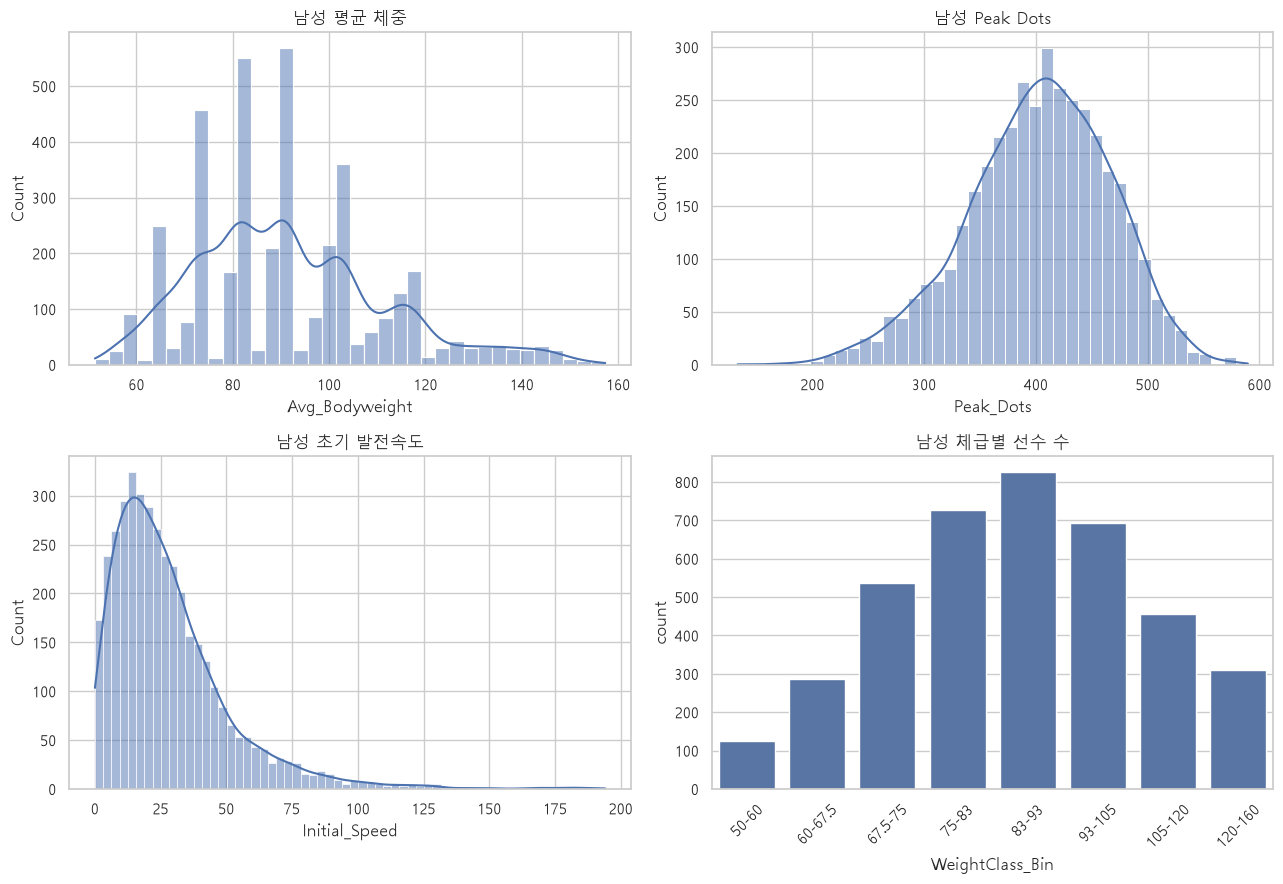


여성 기술통계


,count,mean,std,min,25%,50%,75%,max
Avg_Bodyweight,2024.0,68.013,15.455,41.966,56.156,66.107,74.838,116.335
Career_Start_Age,2024.0,33.194,13.171,12.600,22.000,30.000,42.500,79.000
Career_Start_Year_Normalized,2024.0,21.263,3.594,0.000,19.000,21.000,24.000,28.000
Prior_Competition_Count,2024.0,0.587,1.367,0.000,0.000,0.000,0.250,11.000
Career_WeightClass_Change_Count,2024.0,0.773,0.753,0.000,0.000,1.000,1.000,4.000
Initial_Phase_Change_Count,2024.0,0.025,0.160,0.000,0.000,0.000,0.000,2.000
Peak_Phase_Change_Count,2024.0,0.042,0.209,0.000,0.000,0.000,0.000,2.000
Initial_Speed,2024.0,40.494,26.164,0.172,22.175,35.183,52.435,197.994
Peak_Dots,2024.0,376.731,69.443,154.069,331.861,376.899,425.221,596.266
Days_to_Peak,2024.0,1283.026,765.476,0.000,748.750,1140.000,1710.000,8217.000


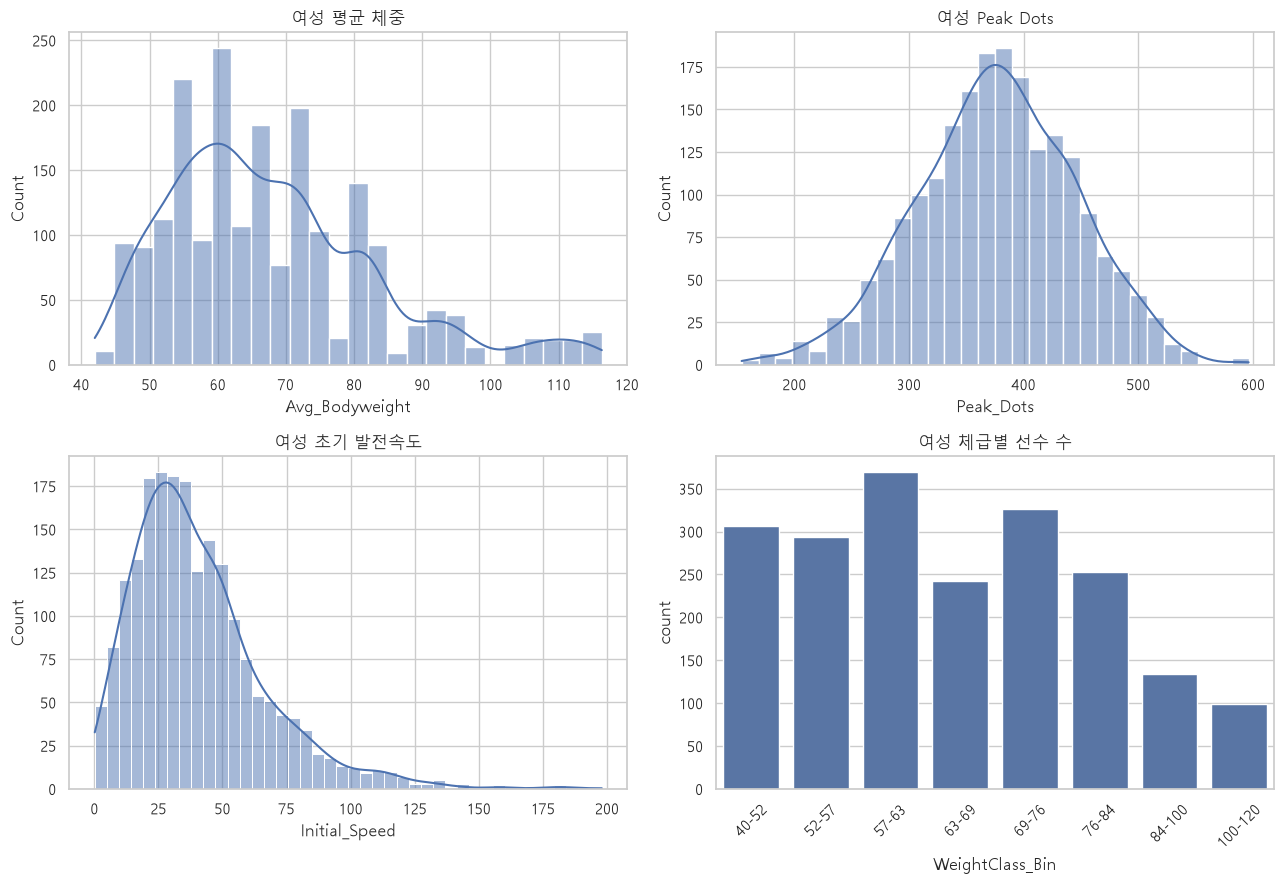

In [68]:
key_numeric = [
    "Avg_Bodyweight", "Career_Start_Age", "Career_Start_Year_Normalized",
    "Prior_Competition_Count", "Career_WeightClass_Change_Count",
    "Initial_Phase_Change_Count", "Peak_Phase_Change_Count",
    "Initial_Speed", "Peak_Dots", "Days_to_Peak", "Peak_Age"
]

descriptive_tables = {}
for sex, df in athlete_data.items():
    descriptive_tables[sex] = df[key_numeric].describe().T
    print(f"\n{SEX_LABEL[sex]} 기술통계")
    display(descriptive_tables[sex].round(3))

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    sns.histplot(df["Avg_Bodyweight"], kde=True, ax=axes[0, 0])
    axes[0, 0].set_title(f"{SEX_LABEL[sex]} 평균 체중")
    sns.histplot(df["Peak_Dots"], kde=True, ax=axes[0, 1])
    axes[0, 1].set_title(f"{SEX_LABEL[sex]} Peak Dots")
    sns.histplot(df["Initial_Speed"], kde=True, ax=axes[1, 0])
    axes[1, 0].set_title(f"{SEX_LABEL[sex]} 초기 발전속도")
    order = WEIGHT_CLASS_CONFIG[sex]["labels"]
    sns.countplot(data=df, x="WeightClass_Bin", order=order, ax=axes[1, 1])
    axes[1, 1].tick_params(axis="x", rotation=45)
    axes[1, 1].set_title(f"{SEX_LABEL[sex]} 체급별 선수 수")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{sex}_descriptive_distributions.png", dpi=160, bbox_inches="tight")
    plt.show()


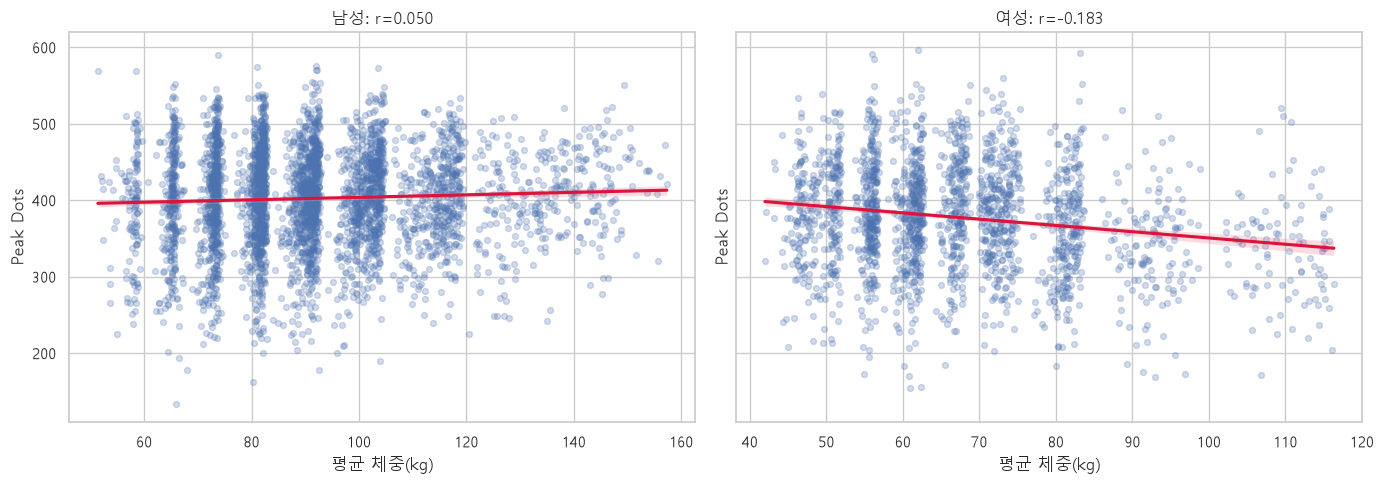

,성별,상관계수,p-value
0,남성,0.049925,1.673973e-03
1,여성,-0.182610,1.231147e-16


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
scatter_summary = []
for ax, sex in zip(axes, ["M", "F"]):
    df = athlete_data[sex]
    corr, pvalue = pearsonr(df["Avg_Bodyweight"], df["Peak_Dots"])
    scatter_summary.append({"성별": SEX_LABEL[sex], "상관계수": corr, "p-value": pvalue})
    sns.regplot(data=df, x="Avg_Bodyweight", y="Peak_Dots",
                scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": "crimson"}, ax=ax)
    ax.set_title(f"{SEX_LABEL[sex]}: r={corr:.3f}")
    ax.set_xlabel("평균 체중(kg)")
    ax.set_ylabel("Peak Dots")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bodyweight_peakdots_scatter.png", dpi=180, bbox_inches="tight")
plt.show()
display(pd.DataFrame(scatter_summary))


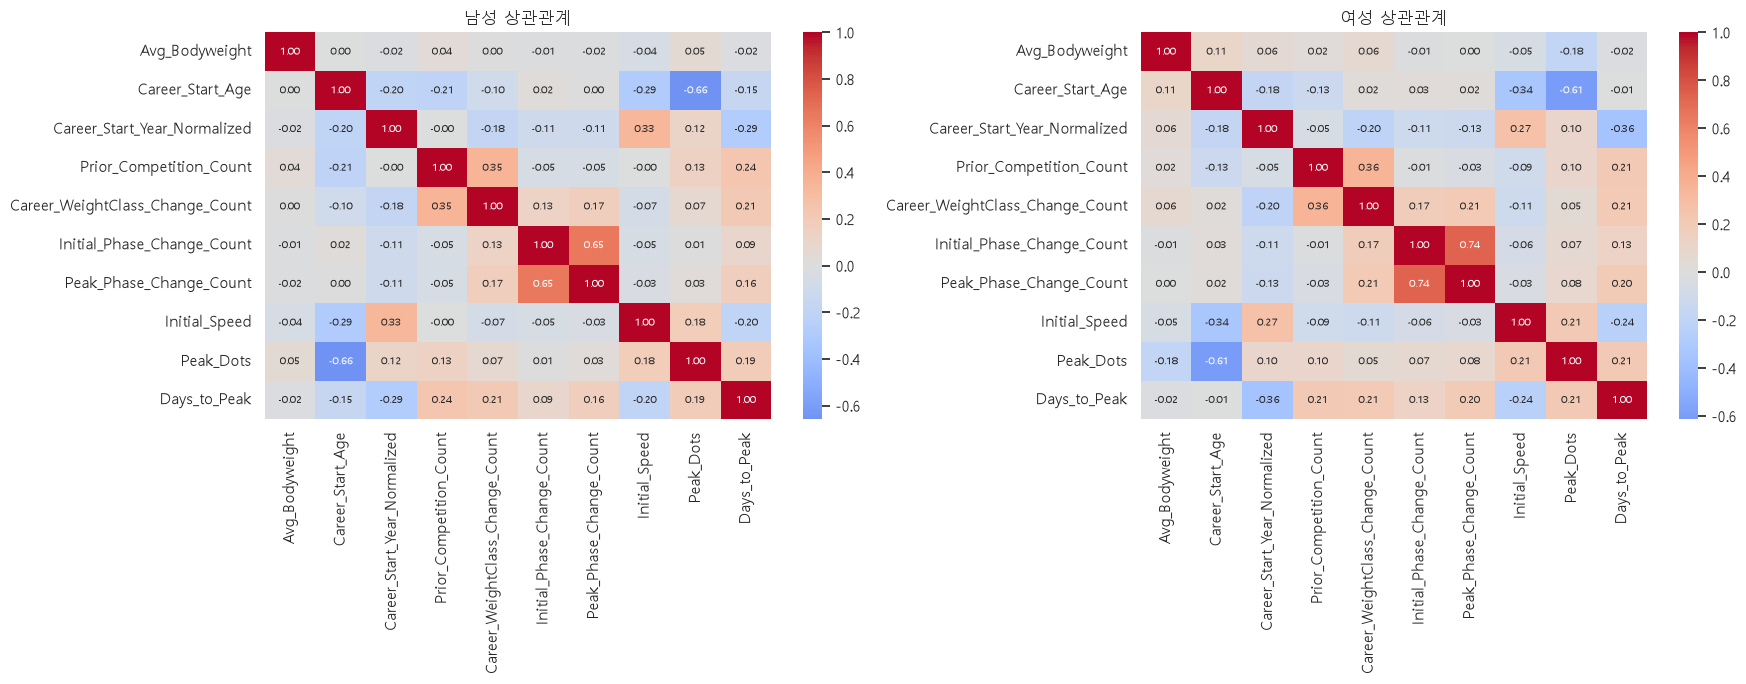

In [70]:
correlation_columns = [
    "Avg_Bodyweight", "Career_Start_Age", "Career_Start_Year_Normalized",
    "Prior_Competition_Count", "Career_WeightClass_Change_Count",
    "Initial_Phase_Change_Count", "Peak_Phase_Change_Count",
    "Initial_Speed", "Peak_Dots", "Days_to_Peak"
]
correlation_tables = {}
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, sex in zip(axes, ["M", "F"]):
    corr = athlete_data[sex][correlation_columns].corr()
    correlation_tables[sex] = corr
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax,
                annot_kws={"fontsize": 7})
    ax.set_title(f"{SEX_LABEL[sex]} 상관관계")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "correlation_heatmaps.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. 다중회귀·VIF·부트스트랩

성별로 세 모형을 적합한다.

- **A:** 체중 → 초기 발전속도
- **E1:** 체중 → Peak Dots, 초기 발전속도 제외
- **E2:** 체중 → Peak Dots, 초기 발전속도 포함

E1과 E2의 체중 계수 변화 및 E2의 초기 발전속도 계수로 매개 가능성을 점검한다.


In [71]:
@dataclass
class OLSResult:
    model: object
    coefficients: pd.DataFrame
    vif: pd.DataFrame
    bootstrap: pd.DataFrame
    features: list[str]


def available_dummies(df: pd.DataFrame):
    ipf = sorted([c for c in df.columns if c.startswith("IPFCategory_")])[1:]
    continent = sorted([c for c in df.columns if c.startswith("Continent_") and c != "Continent_Group"])[1:]
    return ipf, continent


def model_feature_sets(df: pd.DataFrame):
    ipf, continent = available_dummies(df)
    base = [
        "Avg_Bodyweight", "Career_Start_Age", "Career_Start_Year_Normalized",
        "Prior_Competition_Count"
    ]
    return {
        "A": base + ["Initial_Phase_Change_Count"] + ipf + continent,
        "E1": base + ["Peak_Phase_Change_Count", "Days_to_Peak"] + ipf + continent,
        "E2": base + ["Initial_Speed", "Peak_Phase_Change_Count", "Days_to_Peak"] + ipf + continent,
    }


def fit_ols_bootstrap(df, outcome, features, iterations, seed=42):
    work = df[[outcome] + features].dropna().astype(float)
    X = sm.add_constant(work[features], has_constant="add")
    y = work[outcome]
    model = sm.OLS(y, X).fit()

    vif_rows = []
    for index, column in enumerate(X.columns):
        try:
            value = variance_inflation_factor(X.to_numpy(), index)
        except Exception:
            value = np.nan
        vif_rows.append({"Variable": column, "VIF": value})
    vif = pd.DataFrame(vif_rows).set_index("Variable")

    rng = np.random.default_rng(seed)
    boot = []
    n = len(work)
    for _ in tqdm(range(iterations), desc=f"{outcome} bootstrap", leave=False):
        idx = rng.integers(0, n, n)
        sample = work.iloc[idx]
        try:
            sample_X = sm.add_constant(sample[features], has_constant="add")
            fitted = sm.OLS(sample[outcome], sample_X).fit()
            boot.append(fitted.params.reindex(model.params.index).to_numpy())
        except Exception:
            continue

    boot_array = np.asarray(boot)
    boot_se = np.nanstd(boot_array, axis=0, ddof=1)
    boot_p = 2 * (1 - norm.cdf(np.abs(model.params.to_numpy() / boot_se)))
    bootstrap = pd.DataFrame({
        "BS_Mean": np.nanmean(boot_array, axis=0),
        "BS_SE": boot_se,
        "BS_P": boot_p,
        "BS_CI_Lower": np.nanpercentile(boot_array, 2.5, axis=0),
        "BS_CI_Upper": np.nanpercentile(boot_array, 97.5, axis=0),
        "Valid_Iterations": len(boot_array),
    }, index=model.params.index)

    coefficients = pd.DataFrame({
        "Coefficient": model.params,
        "Std_Error": model.bse,
        "t_value": model.tvalues,
        "P_value": model.pvalues,
        "CI_Lower": model.conf_int()[0],
        "CI_Upper": model.conf_int()[1],
    }).join(bootstrap)
    return OLSResult(model, coefficients, vif, bootstrap, features)


In [72]:
ols_results = {}
model_spec = {
    "A": "Initial_Speed",
    "E1": "Peak_Dots",
    "E2": "Peak_Dots",
}

for sex, df in athlete_data.items():
    ols_results[sex] = {}
    features = model_feature_sets(df)
    for model_name, outcome in model_spec.items():
        print(f"\n{SEX_LABEL[sex]} {model_name} 모형: {outcome}")
        result = fit_ols_bootstrap(
            df, outcome, features[model_name], OLS_BOOTSTRAP_ITERATIONS,
            seed=RANDOM_SEED + (0 if sex == "M" else 10) + len(ols_results[sex])
        )
        ols_results[sex][model_name] = result
        display(result.coefficients.round(4))
        print("Adj. R² =", round(result.model.rsquared_adj, 4),
              "| F-test p =", f"{result.model.f_pvalue:.4g}",
              "| N =", int(result.model.nobs))
        print("VIF 최대값(상수 제외) =", round(result.vif.drop(index="const", errors="ignore")["VIF"].max(), 3))



남성 A 모형: Initial_Speed


Initial_Speed bootstrap:   0%|          | 5/1000 [00:00<00:21, 45.78it/s]

,Coefficient,Std_Error,t_value,P_value,CI_Lower,CI_Upper,BS_Mean,BS_SE,BS_P,BS_CI_Lower,BS_CI_Upper,Valid_Iterations
const,8.2126,2.8833,2.8483,0.0044,2.5596,13.8655,8.3825,3.2030,0.0103,2.0757,14.3998,1000
Avg_Bodyweight,-0.0417,0.0169,-2.4684,0.0136,-0.0748,-0.0086,-0.0424,0.0182,0.0220,-0.0783,-0.0048,1000
Career_Start_Age,-0.4020,0.0247,-16.2913,0.0000,-0.4503,-0.3536,-0.4020,0.0250,0.0000,-0.4482,-0.3492,1000
Career_Start_Year_Normalized,1.4971,0.0786,19.0348,0.0000,1.3429,1.6513,1.4921,0.0935,0.0000,1.3092,1.6655,1000
Prior_Competition_Count,-0.8733,0.2518,-3.4687,0.0005,-1.3670,-0.3797,-0.8750,0.3127,0.0052,-1.4644,-0.2364,1000
Initial_Phase_Change_Count,-3.6635,2.3184,-1.5802,0.1142,-8.2089,0.8820,-3.6963,1.9407,0.0591,-7.2941,0.3237,1000
Continent_Europe_Africa,-1.4514,0.6906,-2.1015,0.0357,-2.8054,-0.0974,-1.4468,0.6512,0.0258,-2.7399,-0.1907,1000
Continent_Other,-4.5995,1.4126,-3.2560,0.0011,-7.3691,-1.8300,-4.5729,1.1737,0.0001,-6.7320,-2.2997,1000


Adj. R² = 0.1701 | F-test p = 1.828e-156 | N = 3960
VIF 최대값(상수 제외) = 1.096

남성 E1 모형: Peak_Dots


,Coefficient,Std_Error,t_value,P_value,CI_Lower,CI_Upper,BS_Mean,BS_SE,BS_P,BS_CI_Lower,BS_CI_Upper,Valid_Iterations
const,465.5855,7.3057,63.7292,0.0000,451.2622,479.9088,465.4997,7.4860,0.0000,451.2355,480.5052,1000
Avg_Bodyweight,0.1764,0.0384,4.5891,0.0000,0.1011,0.2518,0.1752,0.0394,0.0000,0.0958,0.2527,1000
Career_Start_Age,-2.9263,0.0571,-51.2601,0.0000,-3.0382,-2.8144,-2.9281,0.0562,0.0000,-3.0366,-2.8159,1000
Career_Start_Year_Normalized,0.3384,0.1889,1.7913,0.0733,-0.0320,0.7087,0.3446,0.1938,0.0809,-0.0298,0.7088,1000
Prior_Competition_Count,-1.4103,0.5886,-2.3961,0.0166,-2.5643,-0.2564,-1.3694,0.6298,0.0251,-2.5874,-0.2252,1000
Peak_Phase_Change_Count,4.5245,4.1391,1.0931,0.2744,-3.5904,12.6394,4.5117,4.3997,0.3038,-4.4726,12.8052,1000
Days_to_Peak,0.0075,0.0009,8.0379,0.0000,0.0057,0.0093,0.0075,0.0012,0.0000,0.0052,0.0099,1000
Continent_Europe_Africa,-0.3169,1.5729,-0.2014,0.8404,-3.4007,2.7670,-0.2627,1.6155,0.8445,-3.2643,2.6084,1000
Continent_Other,-4.0169,3.2187,-1.2480,0.2121,-10.3274,2.2937,-3.8696,2.9463,0.1728,-9.6661,1.6938,1000


...

Adj. R² = 0.1753 | F-test p = 1.749e-81 | N = 2024
VIF 최대값(상수 제외) = 1.098

여성 E1 모형: Peak_Dots


,Coefficient,Std_Error,t_value,P_value,CI_Lower,CI_Upper,BS_Mean,BS_SE,BS_P,BS_CI_Lower,BS_CI_Upper,Valid_Iterations
const,446.5693,10.6023,42.1201,0.0000,425.7767,467.3619,447.1493,10.7266,0.0000,425.4223,466.8115,1000
Avg_Bodyweight,-0.5343,0.0759,-7.0431,0.0000,-0.6830,-0.3855,-0.5371,0.0807,0.0000,-0.6901,-0.3775,1000
Career_Start_Age,-3.0750,0.0912,-33.7152,0.0000,-3.2539,-2.8962,-3.0807,0.0892,0.0000,-3.2568,-2.9090,1000
Career_Start_Year_Normalized,1.8857,0.3523,5.3520,0.0000,1.1947,2.5767,1.8788,0.3565,0.0000,1.2191,2.6236,1000
Prior_Competition_Count,-0.8612,0.8738,-0.9855,0.3245,-2.5748,0.8525,-0.8764,0.9517,0.3655,-2.7657,0.9412,1000
Peak_Phase_Change_Count,18.9692,5.6595,3.3517,0.0008,7.8701,30.0683,18.8328,5.3825,0.0004,8.4726,29.3493,1000
Days_to_Peak,0.0213,0.0017,12.6462,0.0000,0.0180,0.0246,0.0213,0.0019,0.0000,0.0177,0.0250,1000
Continent_Europe_Africa,2.8372,2.4680,1.1496,0.2504,-2.0029,7.6773,2.8525,2.3981,0.2368,-1.7683,7.4728,1000
Continent_Other,-3.1364,4.4288,-0.7082,0.4789,-11.8219,5.5491,-3.1665,4.4123,0.4772,-11.5269,5.3319,1000


Adj. R² = 0.4433 | F-test p = 1.335e-251 | N = 2024
VIF 최대값(상수 제외) = 1.25

여성 E2 모형: Peak_Dots


,Coefficient,Std_Error,t_value,P_value,CI_Lower,CI_Upper,BS_Mean,BS_SE,BS_P,BS_CI_Lower,BS_CI_Upper,Valid_Iterations
const,439.7406,10.8828,40.4069,0.0000,418.3978,461.0833,440.3044,11.4613,0.0000,417.4282,462.1712,1000
Avg_Bodyweight,-0.5272,0.0758,-6.9567,0.0000,-0.6758,-0.3786,-0.5274,0.0810,0.0000,-0.6754,-0.3722,1000
Career_Start_Age,-2.9893,0.0964,-30.9983,0.0000,-3.1784,-2.8001,-2.9898,0.0945,0.0000,-3.1855,-2.8103,1000
Career_Start_Year_Normalized,1.7389,0.3560,4.8852,0.0000,1.0408,2.4370,1.7107,0.3654,0.0000,0.9783,2.4254,1000
Prior_Competition_Count,-0.6444,0.8761,-0.7356,0.4621,-2.3626,1.0737,-0.6502,0.9442,0.4949,-2.6288,1.1883,1000
Initial_Speed,0.1332,0.0493,2.7039,0.0069,0.0366,0.2298,0.1336,0.0533,0.0125,0.0327,0.2352,1000
Peak_Phase_Change_Count,18.5583,5.6527,3.2831,0.0010,7.4726,29.6441,18.2948,5.8198,0.0014,7.0644,29.3868,1000
Days_to_Peak,0.0221,0.0017,12.9451,0.0000,0.0187,0.0254,0.0221,0.0020,0.0000,0.0181,0.0260,1000
Continent_Europe_Africa,2.9757,2.4647,1.2073,0.2274,-1.8579,7.8092,3.0109,2.4797,0.2301,-2.1038,7.9062,1000
Continent_Other,-3.0048,4.4221,-0.6795,0.4969,-11.6772,5.6677,-3.1878,4.2224,0.4767,-11.1737,5.4915,1000


Adj. R² = 0.4451 | F-test p = 5.184e-252 | N = 2024
VIF 최대값(상수 제외) = 1.291


In [73]:
# 핵심 체중·초기속도 계수 비교
key_coefficient_rows = []
for sex in ["M", "F"]:
    for model_name in ["A", "E1", "E2"]:
        table = ols_results[sex][model_name].coefficients
        for variable in ["Avg_Bodyweight", "Initial_Speed"]:
            if variable in table.index:
                row = table.loc[variable]
                key_coefficient_rows.append({
                    "성별": SEX_LABEL[sex], "모형": model_name, "변수": variable,
                    "계수": row["Coefficient"], "p-value": row["P_value"],
                    "BS 95% 하한": row["BS_CI_Lower"], "BS 95% 상한": row["BS_CI_Upper"],
                })
key_coefficients = pd.DataFrame(key_coefficient_rows)
display(key_coefficients.round(4))


,성별,모형,변수,계수,p-value,BS 95% 하한,BS 95% 상한
0,남성,A,Avg_Bodyweight,-0.0417,0.0136,-0.0783,-0.0048
1,남성,E1,Avg_Bodyweight,0.1764,0.0000,0.0958,0.2527
2,남성,E2,Avg_Bodyweight,0.1778,0.0000,0.1048,0.2560
3,남성,E2,Initial_Speed,0.0292,0.4263,-0.0374,0.1039
4,여성,A,Avg_Bodyweight,-0.0520,0.1348,-0.1174,0.0199
5,여성,E1,Avg_Bodyweight,-0.5343,0.0000,-0.6901,-0.3775
6,여성,E2,Avg_Bodyweight,-0.5272,0.0000,-0.6754,-0.3722
7,여성,E2,Initial_Speed,0.1332,0.0069,0.0327,0.2352


### 6-1. 잔차진단


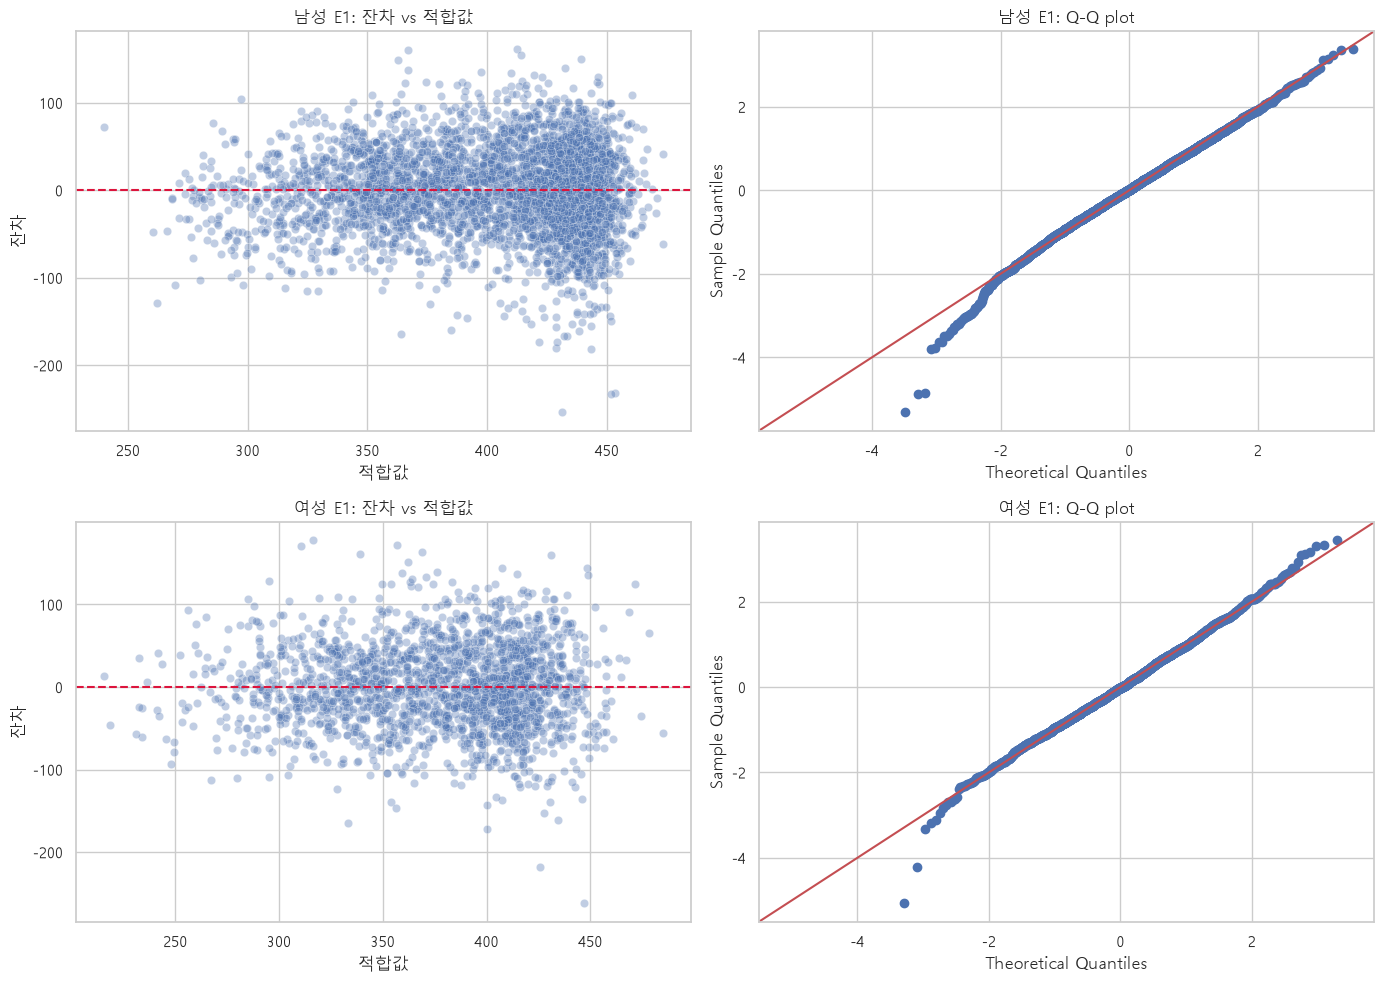

,성별,잔차평균,잔차표준편차,최대 Cook거리
0,남성,0.0,47.75081,0.06273
1,여성,0.0,51.70824,0.04070


In [74]:
residual_diagnostics = []
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row_idx, sex in enumerate(["M", "F"]):
    model = ols_results[sex]["E1"].model
    fitted, residuals = model.fittedvalues, model.resid
    sns.scatterplot(x=fitted, y=residuals, alpha=0.35, ax=axes[row_idx, 0])
    axes[row_idx, 0].axhline(0, color="crimson", linestyle="--")
    axes[row_idx, 0].set_title(f"{SEX_LABEL[sex]} E1: 잔차 vs 적합값")
    axes[row_idx, 0].set_xlabel("적합값")
    axes[row_idx, 0].set_ylabel("잔차")
    sm.qqplot(residuals, line="45", fit=True, ax=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f"{SEX_LABEL[sex]} E1: Q-Q plot")
    residual_diagnostics.append({
        "성별": SEX_LABEL[sex], "잔차평균": residuals.mean(),
        "잔차표준편차": residuals.std(), "최대 Cook거리": model.get_influence().cooks_distance[0].max()
    })
plt.tight_layout()
plt.savefig(FIGURE_DIR / "ols_residual_diagnostics.png", dpi=180, bbox_inches="tight")
plt.show()
display(pd.DataFrame(residual_diagnostics).round(5))


## 7. 초기 발전속도 매개효과


In [75]:
def bootstrap_mediation(df, feature_sets, iterations, seed=42):
    required = sorted(set(["Initial_Speed", "Peak_Dots"] + feature_sets["A"] + feature_sets["E2"]))
    work = df[required].dropna().astype(float)
    rng = np.random.default_rng(seed)
    effects = []
    n = len(work)
    for _ in tqdm(range(iterations), desc="매개효과 bootstrap", leave=False):
        sample = work.iloc[rng.integers(0, n, n)]
        try:
            xa = sm.add_constant(sample[feature_sets["A"]], has_constant="add")
            model_a = sm.OLS(sample["Initial_Speed"], xa).fit()
            xe2 = sm.add_constant(sample[feature_sets["E2"]], has_constant="add")
            model_b = sm.OLS(sample["Peak_Dots"], xe2).fit()
            a = model_a.params["Avg_Bodyweight"]
            b = model_b.params["Initial_Speed"]
            effects.append(a * b)
        except Exception:
            continue
    effects = np.asarray(effects)
    return {
        "Indirect_Effect_Mean": effects.mean(),
        "CI_Lower": np.percentile(effects, 2.5),
        "CI_Upper": np.percentile(effects, 97.5),
        "Valid_Iterations": len(effects),
        "Significant": not (np.percentile(effects, 2.5) <= 0 <= np.percentile(effects, 97.5)),
    }


mediation_rows = []
for sex, df in athlete_data.items():
    row = bootstrap_mediation(
        df, model_feature_sets(df), OLS_BOOTSTRAP_ITERATIONS,
        seed=RANDOM_SEED + (100 if sex == "F" else 0)
    )
    row["성별"] = SEX_LABEL[sex]
    mediation_rows.append(row)
mediation_results = pd.DataFrame(mediation_rows).set_index("성별")
display(mediation_results.round(4))


매개효과 bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

,Indirect_Effect_Mean,CI_Lower,CI_Upper,Valid_Iterations,Significant
성별,,,,,
남성,-0.0011,-0.0049,0.0021,1000,False
여성,-0.0069,-0.0189,0.0015,1000,False


## 8. PSM/CEM과 임계값 민감도 분석

연속형 체중을 Q1-Q3 범위의 무작위 임계값으로 100회 이분화한다. 각 반복에서 높은 체중군을 처치군, 낮은 체중군을 대조군으로 정의한다.

- **PSM:** 로지스틱 성향점수, 1:1 최근접 매칭, 비복원
- **CEM:** 공변량을 4구간으로 조대화하고 처치·대조군이 함께 있는 층만 사용


In [76]:
'''
def causal_covariates(df):
    ipf, continent = available_dummies(df)
    return [
        "Initial_Speed", "Career_Start_Age", "Career_Start_Year_Normalized",
        "Prior_Competition_Count", "Career_WeightClass_Change_Count"
    ] + ipf + continent


def calculate_smd(df, treatment_col, covariates):
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]
    values = {}
    for col in covariates:
        mt, mc = treated[col].mean(), control[col].mean()
        vt, vc = treated[col].var(), control[col].var()
        pooled = np.sqrt((vt + vc) / 2)
        values[col] = 0.0 if not np.isfinite(pooled) or pooled == 0 else (mt - mc) / pooled
    return pd.Series(values)


def psm_match(df, outcome, treatment, covariates, caliper_multiplier=0.1):
    work = df[[outcome, treatment] + covariates].dropna().astype(float).copy()
    if work[treatment].nunique() < 2:
        return None
    X = sm.add_constant(work[covariates], has_constant="add")
    try:
        ps_model = sm.Logit(work[treatment], X).fit(disp=0)
    except Exception:
        ps_model = sm.GLM(work[treatment], X, family=sm.families.Binomial()).fit()
    work["Propensity_Score"] = ps_model.predict(X)
    work["Propensity_Score"] = np.clip(work["Propensity_Score"], 1e-6, 1 - (1e-6))
    logit_ps = np.log(work["Propensity_Score"]/(1-work["Propensity_Score"]))
    caliper = (caliper_multiplier * np.std(logit_ps, ddof=1))
    treated = work[work[treatment] == 1]
    controls = work[work[treatment] == 0].sort_values("Propensity_Score")
    used, indices = set(), []
    for idx, row in treated.sort_values("Propensity_Score").iterrows():
        candidates = controls.loc[~controls.index.isin(used)]
        if candidates.empty:
            break
        distance = (candidates["Propensity_Score"] - row["Propensity_Score"]).abs()
        best = distance.idxmin()
        if distance.loc[best] <= caliper:
            indices.extend([idx, best])
            used.add(best)
    matched = work.loc[indices].drop_duplicates()
    if len(matched) < 50:
        return None
    X_out = sm.add_constant(matched[[treatment] + covariates], has_constant="add")
    model = sm.OLS(matched[outcome], X_out).fit(cov_type="HC3")
    return {"effect": model.params[treatment], "pvalue": model.pvalues[treatment],
            "n": len(matched), "matched": matched}


def cem_match(df, outcome, treatment, covariates, bins=8):
    work = df[[outcome, treatment] + covariates].dropna().astype(float).copy()
    coarse = []
    for col in covariates:
        name = f"__{col}_c"
        if work[col].nunique() <= 2:
            work[name] = work[col].astype(str)
        else:
            work[name] = pd.cut(work[col], bins=bins, labels=False,
                                include_lowest=True, duplicates="drop").astype(str)
        coarse.append(name)
    work["Stratum"] = work[coarse].agg("|".join, axis=1)
    valid = work.groupby("Stratum")[treatment].nunique()
    matched = work[work["Stratum"].isin(valid[valid == 2].index)].copy()
    if len(matched) < 50:
        return None
    model = smf.ols(f"{outcome} ~ {treatment} + C(Stratum)", data=matched).fit(cov_type="HC3")
    return {"effect": model.params[treatment], "pvalue": model.pvalues[treatment],
            "n": len(matched), "matched": matched}


def threshold_sensitivity(df, method, iterations, seed=42):
    outcome, continuous = "Peak_Dots", "Avg_Bodyweight"
    covariates = causal_covariates(df)
    work = df[[outcome, continuous] + covariates].dropna().copy()
    q1, q3 = work[continuous].quantile([0.25, 0.75])
    rng = np.random.default_rng(seed)
    rows = []
    for iteration in tqdm(range(iterations), desc=f"{method} 민감도", leave=False):
        cutoff = rng.uniform(q1, q3)
        sample = work.copy()
        treatment = "Is_Heavy"
        sample[treatment] = (sample[continuous] > cutoff).astype(int)
        try:
            if method == "PSM":
                result = psm_match(
                    sample, outcome, treatment, covariates, caliper_multiplier=0.2
                )
            else:
                result = cem_match(
                    sample, outcome, treatment, covariates, bins=8
                )
            if result:
                rows.append({"iteration": iteration, "cutoff": cutoff,
                             "effect": result["effect"], "pvalue": result["pvalue"], "matched_n": result["n"]})
        except Exception:
            continue
    detail = pd.DataFrame(rows)
    summary = {
        "Method": method,
        "Mean_Effect": detail["effect"].mean(),
        "CI_Lower": detail["effect"].quantile(0.025),
        "CI_Upper": detail["effect"].quantile(0.975),
        "Mean_Matched_N": detail["matched_n"].mean(),
        "Valid_Iterations": len(detail),
    }
    return summary, detail
    '''


'\ndef causal_covariates(df):\n    ipf, continent = available_dummies(df)\n    return [\n        "Initial_Speed", "Career_Start_Age", "Career_Start_Year_Normalized",\n        "Prior_Competition_Count", "Career_WeightClass_Change_Count"\n    ] + ipf + continent\n\n\ndef calculate_smd(df, treatment_col, covariates):\n    treated = df[df[treatment_col] == 1]\n    control = df[df[treatment_col] == 0]\n    values = {}\n    for col in covariates:\n        mt, mc = treated[col].mean(), control[col].mean()\n        vt, vc = treated[col].var(), control[col].var()\n        pooled = np.sqrt((vt + vc) / 2)\n        values[col] = 0.0 if not np.isfinite(pooled) or pooled == 0 else (mt - mc) / pooled\n    return pd.Series(values)\n\n\ndef psm_match(df, outcome, treatment, covariates, caliper_multiplier=0.1):\n    work = df[[outcome, treatment] + covariates].dropna().astype(float).copy()\n    if work[treatment].nunique() < 2:\n        return None\n    X = sm.add_constant(work[covariates], has_constant

In [77]:
# 기존 함수 유지 (ipf, continent 리턴용)
def causal_covariates(df):
    ipf, continent = available_dummies(df)
    return [
        "Initial_Speed", "Career_Start_Age", "Career_Start_Year_Normalized",
        "Prior_Competition_Count", "Career_WeightClass_Change_Count"
    ] + ipf + continent

# 벡터 연산으로 속도가 최적화된 SMD 계산 함수
def calculate_smd(df, treatment_col, covariates):
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]
    values = {}
    for col in covariates:
        mt, mc = treated[col].mean(), control[col].mean()
        vt, vc = treated[col].var(), control[col].var()
        pooled = np.sqrt((vt + vc) / 2)
        values[col] = 0.0 if not np.isfinite(pooled) or pooled == 0 else (mt - mc) / pooled
    return pd.Series(values)

def psm_match(df, outcome, treatment, covariates, caliper_multiplier=0.1): # Caliper를 0.1로 타이트하게 조절
    work = df[[outcome, treatment] + covariates].dropna().astype(float).copy()
    if work[treatment].nunique() < 2:
        return None
        
    X = work[covariates]
    y = work[treatment]
    
    # statsmodels 대비 10배 이상 빠른 sklearn 로지스틱 회귀 사용
    clf = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
    clf.fit(X, y)
    work["Propensity_Score"] = clf.predict_proba(X)[:, 1]
    work["Propensity_Score"] = np.clip(work["Propensity_Score"], 1e-6, 1 - (1e-6))
    
    logit_ps = np.log(work["Propensity_Score"] / (1 - work["Propensity_Score"]))
    caliper = (caliper_multiplier * np.std(logit_ps, ddof=1))
    
    treated = work[work[treatment] == 1].copy()
    controls = work[work[treatment] == 0].copy()

    if len(treated) == 0 or len(controls) == 0:
        return None
    
    # NearestNeighbors를 활용한 고속 복원 추출 매칭
    nn = NearestNeighbors(n_neighbors=min(10, len(controls)), algorithm='auto')
    nn.fit(controls[["Propensity_Score"]])
    
    distances, indices = nn.kneighbors(treated[["Propensity_Score"]])
    
    used_controls = set()
    matched_indices = []
    for t_idx, dist_row, idx_row in zip(treated.index,distances,indices):
        selected_control = None
        for dist, ctrl_pos in zip(dist_row,idx_row):
            ctrl_idx = controls.iloc[ctrl_pos].name
            if ctrl_idx in used_controls:
                continue
            if dist <= caliper:
                selected_control = ctrl_idx
                break
        if selected_control is not None:
            matched_indices.extend([t_idx, selected_control])
            used_controls.add(selected_control)

    if len(matched_indices) < 50:
        return None

    matched = work.loc[matched_indices].copy()

    X_out = sm.add_constant(matched[[treatment] + covariates],has_constant="add")

    model = sm.OLS(matched[outcome],X_out).fit(cov_type="HC3")

    return {
        "effect": model.params[treatment],
        "pvalue": model.pvalues[treatment],
        "n": len(matched),
        "matched": matched,
        "propensity_model": clf,
        "caliper": caliper,
    }


def cem_match(df, outcome, treatment, covariates, bins=8):
    work = df[[outcome, treatment] + covariates].dropna().astype(float).copy()
    coarse = []
    for col in covariates:
        name = f"__{col}_c"
        if work[col].nunique() <= 2:
            work[name] = work[col].astype(str)
        else:
            work[name] = pd.cut(work[col], bins=bins, labels=False,
                                include_lowest=True, duplicates="drop").astype(str)
        coarse.append(name)
    work["Stratum"] = work[coarse].agg("|".join, axis=1)
    valid = work.groupby("Stratum")[treatment].nunique()
    matched = work[work["Stratum"].isin(valid[valid == 2].index)].copy()
    if len(matched) < 50:
        return None
    model = smf.ols(f"{outcome} ~ {treatment} + C(Stratum)", data=matched).fit(cov_type="HC3")
    return {"effect": model.params[treatment], "pvalue": model.pvalues[treatment],
            "n": len(matched), "matched": matched}


# 병렬 처리를 위한 단일 Iteration 작업 함수
def _run_single_iteration(iteration, method, work_df, q1, q3, covariates, outcome, continuous, seed):
    rng = np.random.default_rng(seed + iteration)
    cutoff = rng.uniform(q1, q3)
    sample = work_df.copy()
    treatment = "Is_Heavy"
    sample[treatment] = (sample[continuous] > cutoff).astype(int)
    
    try:
        if method == "PSM":
            result = psm_match(sample, outcome, treatment, covariates, caliper_multiplier=0.1)
        else:
            result = cem_match(sample, outcome, treatment, covariates, bins=8)
            
        if result:
            return {"iteration": iteration, "cutoff": cutoff,
                    "effect": result["effect"], "pvalue": result["pvalue"], "matched_n": result["n"]}
    except Exception:
        pass
    return None


def threshold_sensitivity(df, method, iterations, seed=42):
    outcome, continuous = "Peak_Dots", "Avg_Bodyweight"
    covariates = causal_covariates(df)
    work = df[[outcome, continuous] + covariates].dropna().copy()
    q1, q3 = work[continuous].quantile([0.25, 0.75])
    
    # [핵심] joblib을 이용한 멀티코어 병렬 처리
    results = Parallel(n_jobs=-1)(
        delayed(_run_single_iteration)(i, method, work, q1, q3, covariates, outcome, continuous, seed)
        for i in tqdm(range(iterations), desc=f"{method} 민감도", leave=False)
    )
    
    # None 제거 및 데이터프레임화
    rows = [r for r in results if r is not None]
    detail = pd.DataFrame(rows)
    
    summary = {
        "Method": method,
        "Mean_Effect": detail["effect"].mean() if not detail.empty else np.nan,
        "CI_Lower": detail["effect"].quantile(0.025) if not detail.empty else np.nan,
        "CI_Upper": detail["effect"].quantile(0.975) if not detail.empty else np.nan,
        "Mean_Matched_N": detail["matched_n"].mean() if not detail.empty else np.nan,
        "Valid_Iterations": len(detail),
    }
    return summary, detail

,성별,Method,Mean_Effect,CI_Lower,CI_Upper,Mean_Matched_N,Valid_Iterations
0,남성,PSM,5.3774,2.2966,9.3911,2774.90,100
1,남성,CEM,1.7820,-1.4704,5.3892,3261.72,100
2,여성,PSM,-13.1559,-21.9700,-7.5489,1374.78,100
3,여성,CEM,-18.0342,-25.7598,-14.2108,1274.00,100


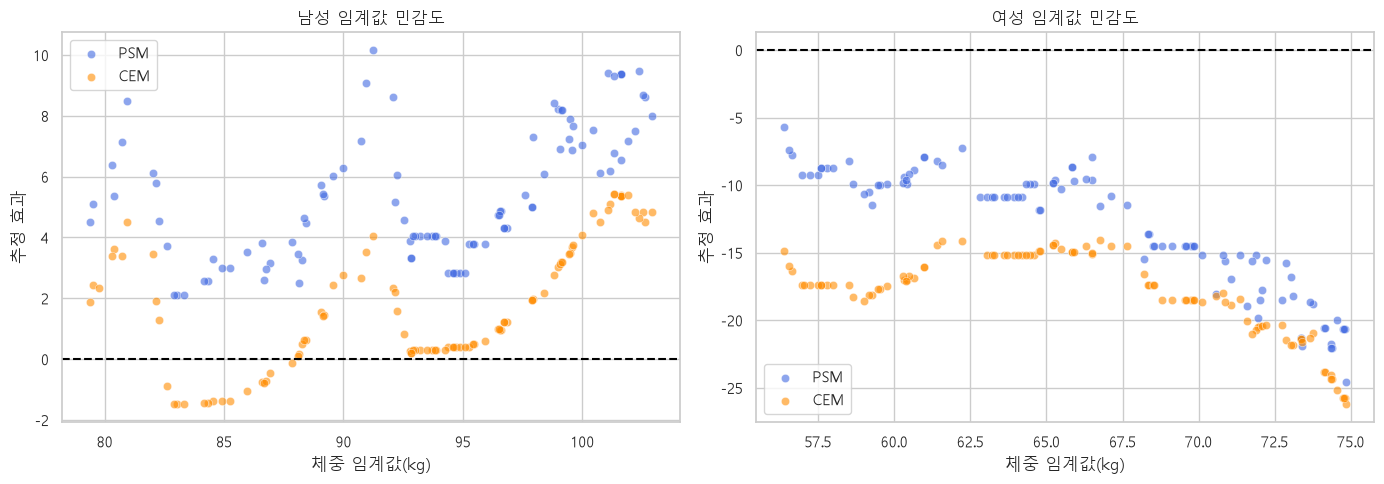

In [78]:
matching_summaries, matching_details = [], {}
for sex, df in athlete_data.items():
    matching_details[sex] = {}
    for method in ["PSM", "CEM"]:
        summary, detail = threshold_sensitivity(
            df, method, MATCHING_ITERATIONS,
            seed=RANDOM_SEED + (1000 if sex == "F" else 0) + (1 if method == "CEM" else 0)
        )
        summary["Sex"] = sex
        matching_summaries.append(summary)
        matching_details[sex][method] = detail

matching_summary = pd.DataFrame(matching_summaries)
matching_summary["성별"] = matching_summary["Sex"].map(SEX_LABEL)
display(matching_summary[["성별", "Method", "Mean_Effect", "CI_Lower", "CI_Upper",
                          "Mean_Matched_N", "Valid_Iterations"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sex in zip(axes, ["M", "F"]):
    for method, color in [("PSM", "royalblue"), ("CEM", "darkorange")]:
        detail = matching_details[sex][method]
        sns.scatterplot(data=detail, x="cutoff", y="effect", alpha=0.6,
                        label=method, color=color, ax=ax)
    ax.axhline(0, color="black", linestyle="--")
    ax.set_title(f"{SEX_LABEL[sex]} 임계값 민감도")
    ax.set_xlabel("체중 임계값(kg)")
    ax.set_ylabel("추정 효과")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "matching_threshold_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()


### 8-1. PSM/CEM Love plot


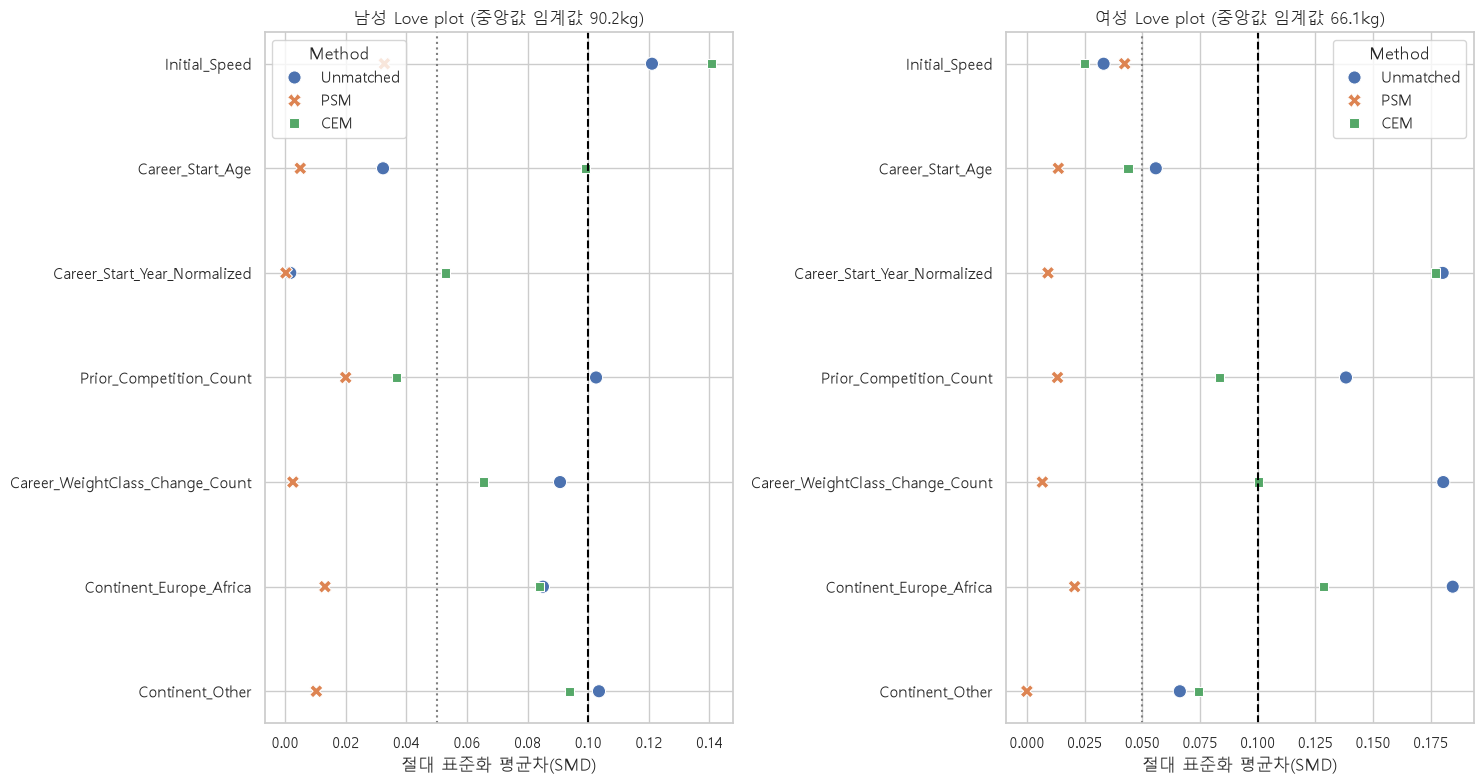

In [79]:
balance_tables = {}
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
for ax, sex in zip(axes, ["M", "F"]):
    df = athlete_data[sex].copy()
    covariates = causal_covariates(df)
    cutoff = df["Avg_Bodyweight"].median()
    df["Is_Heavy"] = (df["Avg_Bodyweight"] > cutoff).astype(int)
    base = df.dropna(subset=["Peak_Dots", "Is_Heavy"] + covariates).copy()
    unmatched = calculate_smd(base, "Is_Heavy", covariates).abs()
    psm = psm_match(base, "Peak_Dots", "Is_Heavy", covariates)
    cem = cem_match(base, "Peak_Dots", "Is_Heavy", covariates)
    psm_smd = calculate_smd(psm["matched"], "Is_Heavy", covariates).abs() if psm else pd.Series(np.nan, index=covariates)
    cem_smd = calculate_smd(cem["matched"], "Is_Heavy", covariates).abs() if cem else pd.Series(np.nan, index=covariates)
    balance = pd.DataFrame({"Unmatched": unmatched, "PSM": psm_smd, "CEM": cem_smd})
    balance_tables[sex] = balance
    long = balance.reset_index(names="Covariate").melt(
        id_vars="Covariate", var_name="Method", value_name="Absolute_SMD"
    )
    sns.scatterplot(data=long, x="Absolute_SMD", y="Covariate", hue="Method",
                    style="Method", s=90, ax=ax)
    ax.axvline(0.1, color="black", linestyle="--")
    ax.axvline(0.05, color="gray", linestyle=":")
    ax.set_title(f"{SEX_LABEL[sex]} Love plot (중앙값 임계값 {cutoff:.1f}kg)")
    ax.set_xlabel("절대 표준화 평균차(SMD)")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "psm_cem_love_plots.png", dpi=180, bbox_inches="tight")
plt.show()


## 9. 연속형 처치 GPS Weighting-Based Dose-Response Analysis과 RCS 용량-반응 곡선

1. 랜덤포레스트로 공변량 조건부 체중을 예측한다.
2. 잔차 KDE로 GPS를 계산한다.
3. 주변 체중 밀도/GPS로 안정화 가중치를 만들고 1·99백분위에서 절단한다.
4. 가중 restricted cubic spline 결과모형을 적합한다.
5. 동일 체중 그리드에서 부트스트랩 신뢰구간을 계산한다.


In [80]:
def weighted_corr(x, y, weights):
    x, y, weights = np.asarray(x), np.asarray(y), np.asarray(weights)
    mx, my = np.average(x, weights=weights), np.average(y, weights=weights)
    numerator = np.sum(weights * (x - mx) * (y - my))
    denominator = np.sqrt(np.sum(weights * (x - mx) ** 2) * np.sum(weights * (y - my) ** 2))
    return numerator / denominator if denominator > 0 else np.nan


def gps_dr_fit(df, treatment_grid=None, seed=42, diagnostics=False):
    outcome, treatment = "Peak_Dots", "Avg_Bodyweight"
    covariates = causal_covariates(df)
    work = df[[outcome, treatment] + covariates].dropna().astype(float).copy()
    X, T, Y = work[covariates], work[treatment], work[outcome]

    treatment_model = RandomForestRegressor(
        n_estimators=200, min_samples_leaf=5, random_state=seed, n_jobs=-1
    )
    treatment_model.fit(X, T)
    residual = T - treatment_model.predict(X)
    std = float(np.std(residual, ddof=1))
    bandwidth = max(1e-3, 1.06 * std * len(residual) ** (-1 / 5))
    conditional_kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(
        residual.to_numpy().reshape(-1, 1)
    )
    gps = np.exp(conditional_kde.score_samples(residual.to_numpy().reshape(-1, 1)))
    marginal_kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(
        T.to_numpy().reshape(-1, 1)
    )
    numerator = np.exp(marginal_kde.score_samples(T.to_numpy().reshape(-1, 1)))
    weights = numerator / np.maximum(gps, 1e-12)
    lower, upper = np.percentile(weights, [1, 99])
    weights = np.clip(weights, lower, upper)

    knots = np.percentile(T, [5, 25, 50, 75, 95])
    interior = list(knots[1:-1])
    formula = (
        f"{outcome} ~ cr({treatment}, knots={interior}, "
        f"lower_bound={knots[0]}, upper_bound={knots[-1]}) + " + " + ".join(covariates)
    )
    model = smf.wls(formula=formula, data=work, weights=weights).fit(cov_type="HC3")
    grid = treatment_grid if treatment_grid is not None else np.linspace(T.quantile(0.01), T.quantile(0.99), 100)
    curve = []
    for t in grid:
        prediction = work.copy()
        prediction[treatment] = t
        pred = model.predict(prediction)
        curve.append(np.mean(pred))
    curve = np.asarray(curve, dtype=float)

    balance = pd.DataFrame({
        "Covariate": covariates,
        "Unadjusted_Abs_Corr": [abs(pearsonr(X[c], T)[0]) for c in covariates],
        "Weighted_Abs_Corr": [abs(weighted_corr(X[c], T, weights)) for c in covariates],
    })
    diagnostics_dict = {
        "N": len(work), "Bandwidth": bandwidth,
        "Weight_Min": weights.min(), "Weight_Median": np.median(weights),
        "Weight_Max": weights.max(), "Effective_Sample_Size": weights.sum() ** 2 / np.sum(weights ** 2),
    }
    return {"grid": np.asarray(grid), "curve": curve, "balance": balance,
            "weights": weights, "model": model, "diagnostics": diagnostics_dict}


def gps_bootstrap(df, iterations, seed=42):
    base = gps_dr_fit(df, seed=seed, diagnostics=True)
    grid = base["grid"]
    rng = np.random.default_rng(seed)
    curves = []
    for i in tqdm(range(iterations), desc="GPS-DR bootstrap", leave=False):
        sample = df.iloc[rng.integers(0, len(df), len(df))].copy()
        try:
            fitted = gps_dr_fit(sample, treatment_grid=grid, seed=seed + i + 1)
            curves.append(fitted["curve"])
        except Exception:
            continue
    curves = np.asarray(curves)
    return base, pd.DataFrame({
        "Bodyweight": grid,
        "Estimated_Peak_Dots": np.mean(curves, axis=0),
        "CI_Lower": np.percentile(curves, 2.5, axis=0),
        "CI_Upper": np.percentile(curves, 97.5, axis=0),
        "Valid_Iterations": len(curves),
    })



남성 GPS-DR



여성 GPS-DR


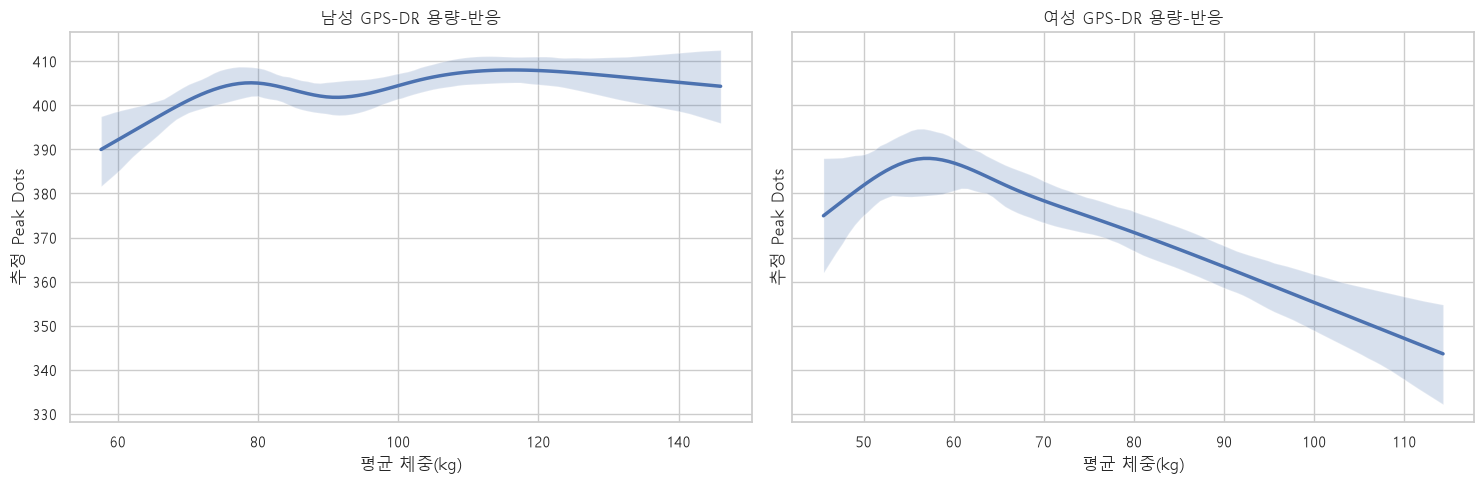

,성별,N,Bandwidth,Weight_Min,Weight_Median,Weight_Max,Effective_Sample_Size,Valid_Bootstrap
0,남성,3960,2.9618,0.305,0.8267,2.4995,3434.6185,100
1,여성,2024,2.6641,0.304,0.7680,3.4611,1578.0601,100


In [81]:
gps_results, gps_curves, gps_diagnostics = {}, {}, []
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, sex in zip(axes, ["M", "F"]):
    print(f"\n{SEX_LABEL[sex]} GPS-DR")
    base, curve = gps_bootstrap(
        athlete_data[sex], GPS_BOOTSTRAP_ITERATIONS,
        seed=RANDOM_SEED + (5000 if sex == "F" else 0)
    )
    gps_results[sex], gps_curves[sex] = base, curve
    gps_diagnostics.append({"성별": SEX_LABEL[sex], **base["diagnostics"],
                            "Valid_Bootstrap": int(curve["Valid_Iterations"].iloc[0])})
    ax.plot(curve["Bodyweight"], curve["Estimated_Peak_Dots"], linewidth=2.5)
    ax.fill_between(curve["Bodyweight"], curve["CI_Lower"], curve["CI_Upper"], alpha=0.22)
    ax.set_title(f"{SEX_LABEL[sex]} GPS-DR 용량-반응")
    ax.set_xlabel("평균 체중(kg)")
    ax.set_ylabel("추정 Peak Dots")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "gps_dr_dose_response.png", dpi=180, bbox_inches="tight")
plt.show()
display(pd.DataFrame(gps_diagnostics).round(4))


### 9-1. GPS 가중 전후 공변량 균형


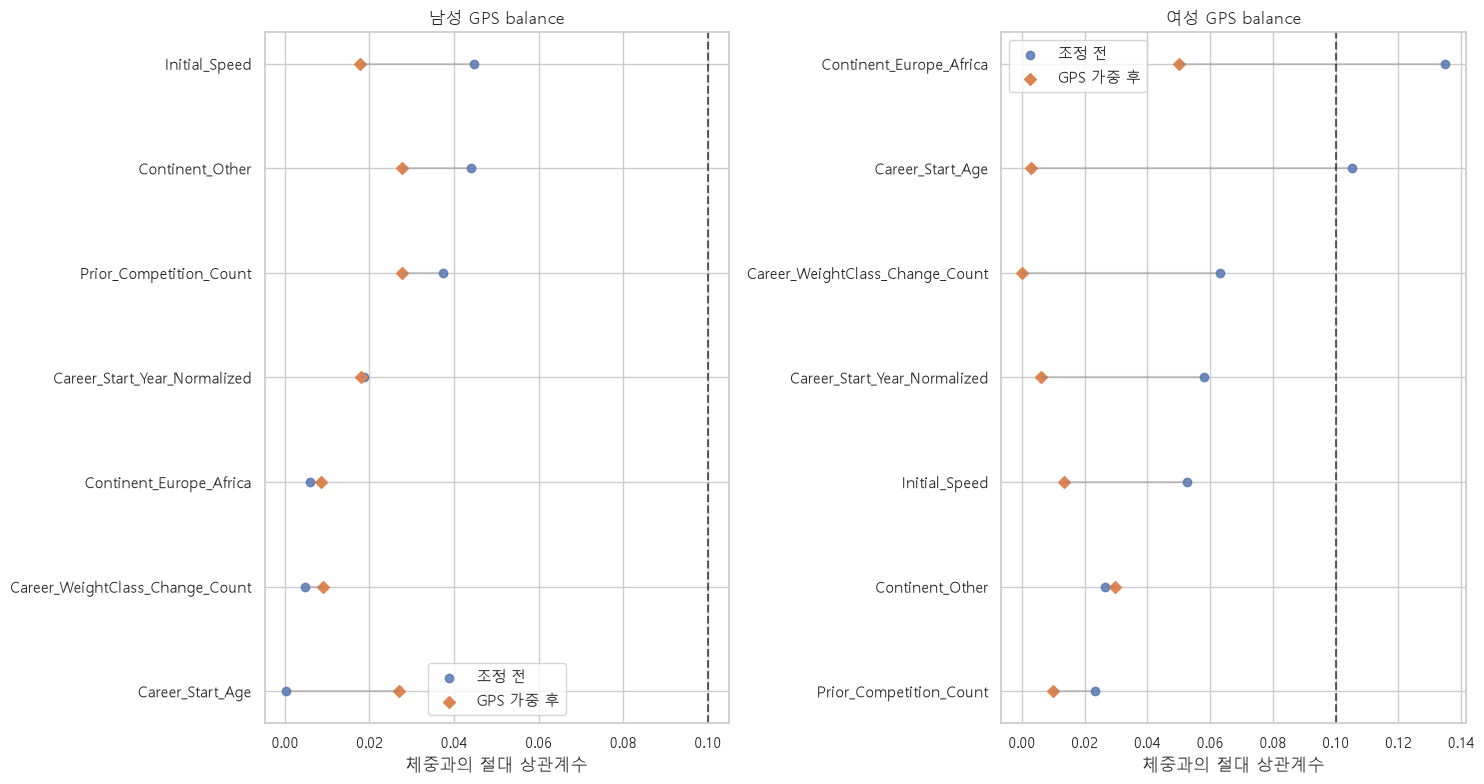

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
for ax, sex in zip(axes, ["M", "F"]):
    balance = gps_results[sex]["balance"].sort_values("Unadjusted_Abs_Corr")
    for _, row in balance.iterrows():
        ax.hlines(row["Covariate"], row["Weighted_Abs_Corr"], row["Unadjusted_Abs_Corr"],
                  color="gray", alpha=0.35)
    ax.scatter(balance["Unadjusted_Abs_Corr"], balance["Covariate"], label="조정 전", alpha=0.8)
    ax.scatter(balance["Weighted_Abs_Corr"], balance["Covariate"], label="GPS 가중 후", marker="D")
    ax.axvline(0.1, color="black", linestyle="--", alpha=0.6)
    ax.set_title(f"{SEX_LABEL[sex]} GPS balance")
    ax.set_xlabel("체중과의 절대 상관계수")
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "gps_balance_love_plots.png", dpi=180, bbox_inches="tight")
plt.show()


## 10. 체급별 결과와 EMA 궤적 예시


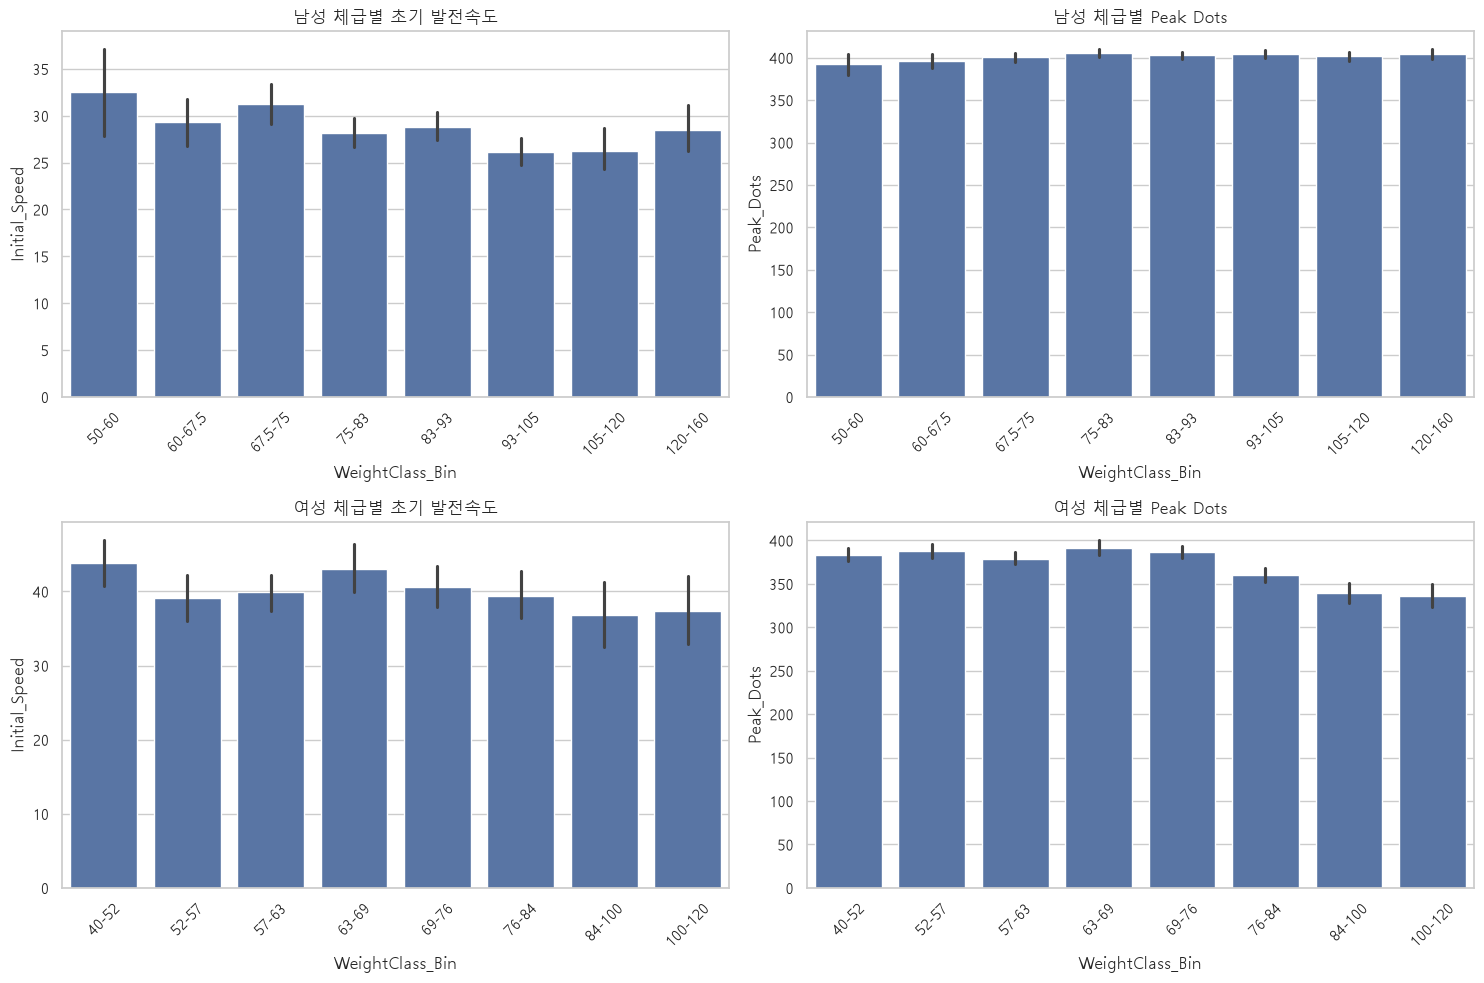

In [93]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for row, sex in enumerate(["M", "F"]):
    order = WEIGHT_CLASS_CONFIG[sex]["labels"]
    sns.barplot(data=athlete_data[sex], x="WeightClass_Bin", y="Initial_Speed", order=order, ax=axes[row, 0])
    axes[row, 0].set_title(f"{SEX_LABEL[sex]} 체급별 초기 발전속도")
    axes[row, 0].tick_params(axis="x", rotation=45)
    sns.barplot(data=athlete_data[sex], x="WeightClass_Bin", y="Peak_Dots", order=order, ax=axes[row, 1])
    axes[row, 1].set_title(f"{SEX_LABEL[sex]} 체급별 Peak Dots")
    axes[row, 1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "weightclass_summary.png", dpi=180, bbox_inches="tight")
plt.show()


In [100]:
# REBUILD_ATHLETE_FEATURES=True로 실행한 경우 궤적 예시를 표시한다.
available_trajectory_count = sum(len(v) for v in trajectories.values())
if available_trajectory_count == 0:
    print("캐시를 사용해 궤적 객체가 없습니다. 궤적 예시가 필요하면 REBUILD_ATHLETE_FEATURES=True로 재실행하세요.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    for row, sex in enumerate(["M", "F"]):
        sample_names = athlete_data[sex].sample(
            n=min(3, len(athlete_data[sex])), random_state=RANDOM_SEED
        )["Name"].tolist()
        for col, name in enumerate(sample_names):
            traj = trajectories[sex][name]
            axes[row, col].plot(traj["Days_Since_Start"] / 365.0, traj["Dots"], linewidth=2)
            peak = traj.loc[traj["Dots"].idxmax()]
            axes[row, col].scatter(peak["Days_Since_Start"] / 365.0, peak["Dots"], color="crimson")
            axes[row, col].set_title(f"{SEX_LABEL[sex]} | {name}")
            axes[row, col].set_xlabel("경력 연수")
            axes[row, col].set_ylabel("EMA Dots")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "ema_trajectory_examples.png", dpi=180, bbox_inches="tight")
    plt.show()


캐시를 사용해 궤적 객체가 없습니다. 궤적 예시가 필요하면 REBUILD_ATHLETE_FEATURES=True로 재실행하세요.


## 11. 결과 저장


In [101]:
# 상세 반복 결과 CSV
for sex in ["M", "F"]:
    for method in ["PSM", "CEM"]:
        matching_details[sex][method].to_csv(
            TABLE_DIR / f"{sex}_{method}_threshold_iterations.csv", index=False, encoding="utf-8-sig"
        )
    gps_curves[sex].to_csv(TABLE_DIR / f"{sex}_GPS_DRF.csv", index=False, encoding="utf-8-sig")

workbook_path = OUTPUT_DIR / "powerlifting_causal_analysis_results.xlsx"
with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:
    input_overview.to_excel(writer, sheet_name="Input_Overview", index=False)
    quality_table.to_excel(writer, sheet_name="Input_Quality", index=False)
    extracted_overview.to_excel(writer, sheet_name="Athlete_Overview", index=False)
    key_coefficients.to_excel(writer, sheet_name="OLS_Key_Coefficients", index=False)
    mediation_results.to_excel(writer, sheet_name="Mediation")
    matching_summary.to_excel(writer, sheet_name="Matching_Summary", index=False)
    pd.DataFrame(gps_diagnostics).to_excel(writer, sheet_name="GPS_Diagnostics", index=False)
    for sex in ["M", "F"]:
        descriptive_tables[sex].to_excel(writer, sheet_name=f"{sex}_Descriptive")
        correlation_tables[sex].to_excel(writer, sheet_name=f"{sex}_Correlation")
        balance_tables[sex].to_excel(writer, sheet_name=f"{sex}_Matching_Balance")
        gps_results[sex]["balance"].to_excel(writer, sheet_name=f"{sex}_GPS_Balance", index=False)
        gps_curves[sex].to_excel(writer, sheet_name=f"{sex}_GPS_Curve", index=False)
        for model_name in ["A", "E1", "E2"]:
            ols_results[sex][model_name].coefficients.to_excel(
                writer, sheet_name=f"{sex}_{model_name}_OLS"
            )
            ols_results[sex][model_name].vif.to_excel(
                writer, sheet_name=f"{sex}_{model_name}_VIF"
            )

run_metadata = {
    "FULL_RUN": FULL_RUN,
    "random_seed": RANDOM_SEED,
    "ols_bootstrap_iterations": OLS_BOOTSTRAP_ITERATIONS,
    "matching_iterations": MATCHING_ITERATIONS,
    "gps_bootstrap_iterations": GPS_BOOTSTRAP_ITERATIONS,
    "input_files": {sex: str(path) for sex, path in DATA_PATHS.items()},
    "analysis_counts": {sex: int(len(df)) for sex, df in athlete_data.items()},
}
(OUTPUT_DIR / "run_metadata.json").write_text(
    json.dumps(run_metadata, ensure_ascii=False, indent=2), encoding="utf-8"
)

print("저장 완료:", workbook_path)
print("그림 폴더:", FIGURE_DIR)
print("상세 표 폴더:", TABLE_DIR)


저장 완료: c:\python\powerlift_causal_analysis\outputs\powerlifting_causal_analysis_results.xlsx
그림 폴더: c:\python\powerlift_causal_analysis\outputs\figures
상세 표 폴더: c:\python\powerlift_causal_analysis\outputs\tables


## 12. 해석 체크리스트

실행 후 아래 항목을 순서대로 확인한다.

1. 선수 수준 분석 표본 수가 예상 범위인지 확인한다.
2. E1 체중 계수의 방향과 부트스트랩 신뢰구간을 확인한다.
3. A와 E2를 통해 간접효과 신뢰구간이 0을 포함하는지 확인한다.
4. PSM/CEM 임계값 변화에도 효과 방향이 유지되는지 확인한다.
5. Love plot에서 조정 후 SMD 또는 절대 상관계수가 0.1 근처 또는 아래로 감소했는지 확인한다.
6. GPS-DR 곡선의 방향, 비선형성, 신뢰구간 폭을 확인한다.
7. 잔차 플롯과 영향점, GPS 유효표본크기를 보고 모델의 불안정성을 점검한다.

결과가 기존 보고서와 다르면 먼저 입력 CSV 버전, 분석 선수 수, `FULL_RUN`, 무작위 시드와 전처리 조건을 확인한다.
